# Junction Decode Analysis

Analyze what the neural decoder represents at every 3-way junction in the maze.
For each junction encounter: does the decode anticipate the left or right branch,
and which way did the rat actually go?

In [1]:
import matplotlib.pyplot as plt
import datajoint as dj
import numpy as np
import pandas as pd

from hexmaze import (
    plot_hex_maze,
    get_all_choice_points,
    get_critical_choice_points,
    get_junction_left_right_map,
    get_hex_centroids,
    maze_to_graph,
)

import spyglass.common as sgc
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexMazeChoice, HexCentroids
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeJunctionDecode,
    HexMazeDecodedPositionHexAnnotated,
)

# Select session
key = {"nwb_file_name": "Toby20250316_.nwb", "epoch": 5}
display(HexMazeBlock() & key)

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-04-19 12:40:23,974][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
Toby20250316_.nwb,5,1,"7,10,19,21,22,24,35,42,43,46",epoch5_block1,90.0,10.0,50.0,69,probability change
Toby20250316_.nwb,5,2,"7,10,19,21,22,24,35,42,43,46",epoch5_block2,50.0,90.0,10.0,69,probability change
Toby20250316_.nwb,5,3,"7,10,19,21,22,24,35,42,43,46",epoch5_block3,50.0,10.0,90.0,69,probability change


In [2]:
# Take inventory of how many tables we have access to
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPositionHex, HexMazeDecodedPositionHexAnnotated, HexMazeJunctionDecode

results = {}
for key in HexMazeDecodedPositionHex.fetch('KEY'):
    try:
        df = (HexMazeDecodedPositionHex & key).fetch1_dataframe()
        results[frozenset(key.items())] = df
        print("OK:", key)
    except (ValueError, FileNotFoundError) as e:
        print("SKIP (NWB read error):", key, "|", e)

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

OK: {'decoding_merge_id': UUID('14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf'), 'nwb_file_name': 'IM-1478_20220719_.nwb', 'epoch': 0}


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

OK: {'decoding_merge_id': UUID('5b8a121f-5e12-c8a3-95dc-e48d3bb97295'), 'nwb_file_name': 'IM-1478_20220720_.nwb', 'epoch': 0}


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

...

OK: {'decoding_merge_id': UUID('aee87e27-ca98-4645-9051-85d52378942c'), 'nwb_file_name': 'Toby20250327_.nwb', 'epoch': 1}


[12:42:26][INFO] Spyglass: NWB file not found locally; checking kachery for /stelmo/nwb/analysis/Toby20250327/Toby20250327_97TXPLWG57.nwb
INFO:spyglass:NWB file not found locally; checking kachery for /stelmo/nwb/analysis/Toby20250327/Toby20250327_97TXPLWG57.nwb
[12:42:26][INFO] Spyglass: NWB file not found in kachery; checking Dandi for /stelmo/nwb/analysis/Toby20250327/Toby20250327_97TXPLWG57.nwb
INFO:spyglass:NWB file not found in kachery; checking Dandi for /stelmo/nwb/analysis/Toby20250327/Toby20250327_97TXPLWG57.nwb


SKIP (NWB read error): {'decoding_merge_id': UUID('b94510ec-58c2-a1a9-f212-58b740944172'), 'nwb_file_name': 'Toby20250327_.nwb', 'epoch': 7} | NWB file not found in kachery or Dandi: Toby20250327_97TXPLWG57.nwb.


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

OK: {'decoding_merge_id': UUID('e7b6f591-0016-95ca-3c5c-76426ab81366'), 'nwb_file_name': 'Toby20250327_.nwb', 'epoch': 5}


In [3]:
key = {"nwb_file_name": "IM-1478_20220725_.nwb"}
df = (HexMazeDecodedPositionHex & key).fetch1_dataframe()
df

,position_x,position_y,orientation,velocity_x,velocity_y,speed,hex,decode_position_x,decode_position_y,decode_hex,decode_distance,decode_hex_distance,hpd_thresh,spatial_cov
time,,,,,,,,,,,,,,
12.513374,90.645172,112.298968,2.592253,3.642322,-8.596940,9.336695,36,95.912552,124.072319,41,12.897950,1,0.003681,69
12.515374,90.661739,112.287255,2.591226,3.605933,-8.414944,9.155001,36,93.915783,124.072319,41,12.226060,1,0.002909,74
12.517374,90.678307,112.275542,2.590199,3.567587,-8.230246,8.970208,36,91.919013,124.072319,41,11.861843,1,0.002933,77
12.519374,90.694874,112.263829,2.589172,3.527295,-8.042923,8.782393,36,91.919013,124.072319,41,11.871771,1,0.002725,80
12.521374,90.711442,112.252116,2.588146,3.485071,-7.853053,8.591633,36,91.919013,124.072319,41,11.881727,1,0.002620,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4876.159106,35.317122,131.472083,2.363328,-0.105210,0.686340,0.694357,2,34.012693,136.040974,2,4.751453,0,0.001152,126
4876.161106,35.321200,131.476778,2.361982,-0.112388,0.690404,0.699492,2,34.012693,136.040974,2,4.748060,0,0.001077,137
4876.163106,35.325277,131.481473,2.360634,-0.119628,0.694488,0.704716,2,34.012693,136.040974,2,4.744673,0,0.000951,148


## Fetch junction decode data

In [4]:
# Populate the table if not already done
# HexMazeJunctionDecode.populate(key)

df = (HexMazeJunctionDecode & key).fetch1_dataframe()

# Filter out timepoints outside trials
df = df[df["hex"] != -100]

# Summary of junctions found
junc_df = df[df["nearest_junction"] != -100]
print(f"Total timepoints: {len(df):,}")
print(f"Timepoints near a junction: {len(junc_df):,} ({100*len(junc_df)/len(df):.1f}%)")
print(f"Unique junctions visited: {junc_df['nearest_junction'].nunique()}")
print()

# Count junction encounters (at the junction itself, hexes_from_junction == 0)
at_junc = df[df["hexes_from_junction"] == 0]
encounters = at_junc.groupby(["epoch_trial_num", "nearest_junction"]).ngroups
print(f"Total junction encounters: {encounters}")

[2026-04-19 12:46:09,958][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 12:46:09,968][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

Total timepoints: 2,431,828
Timepoints near a junction: 1,841,684 (75.7%)
Unique junctions visited: 15

Total junction encounters: 1294


{'nwb_file_name': 'IM-1478_20220725_.nwb', 'epoch': 0, 'block': 1}: barrier change session for the hex maze task with 3 blocks and 188 trials.


[2026-04-19 13:40:24,624][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 13:40:24,635][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb


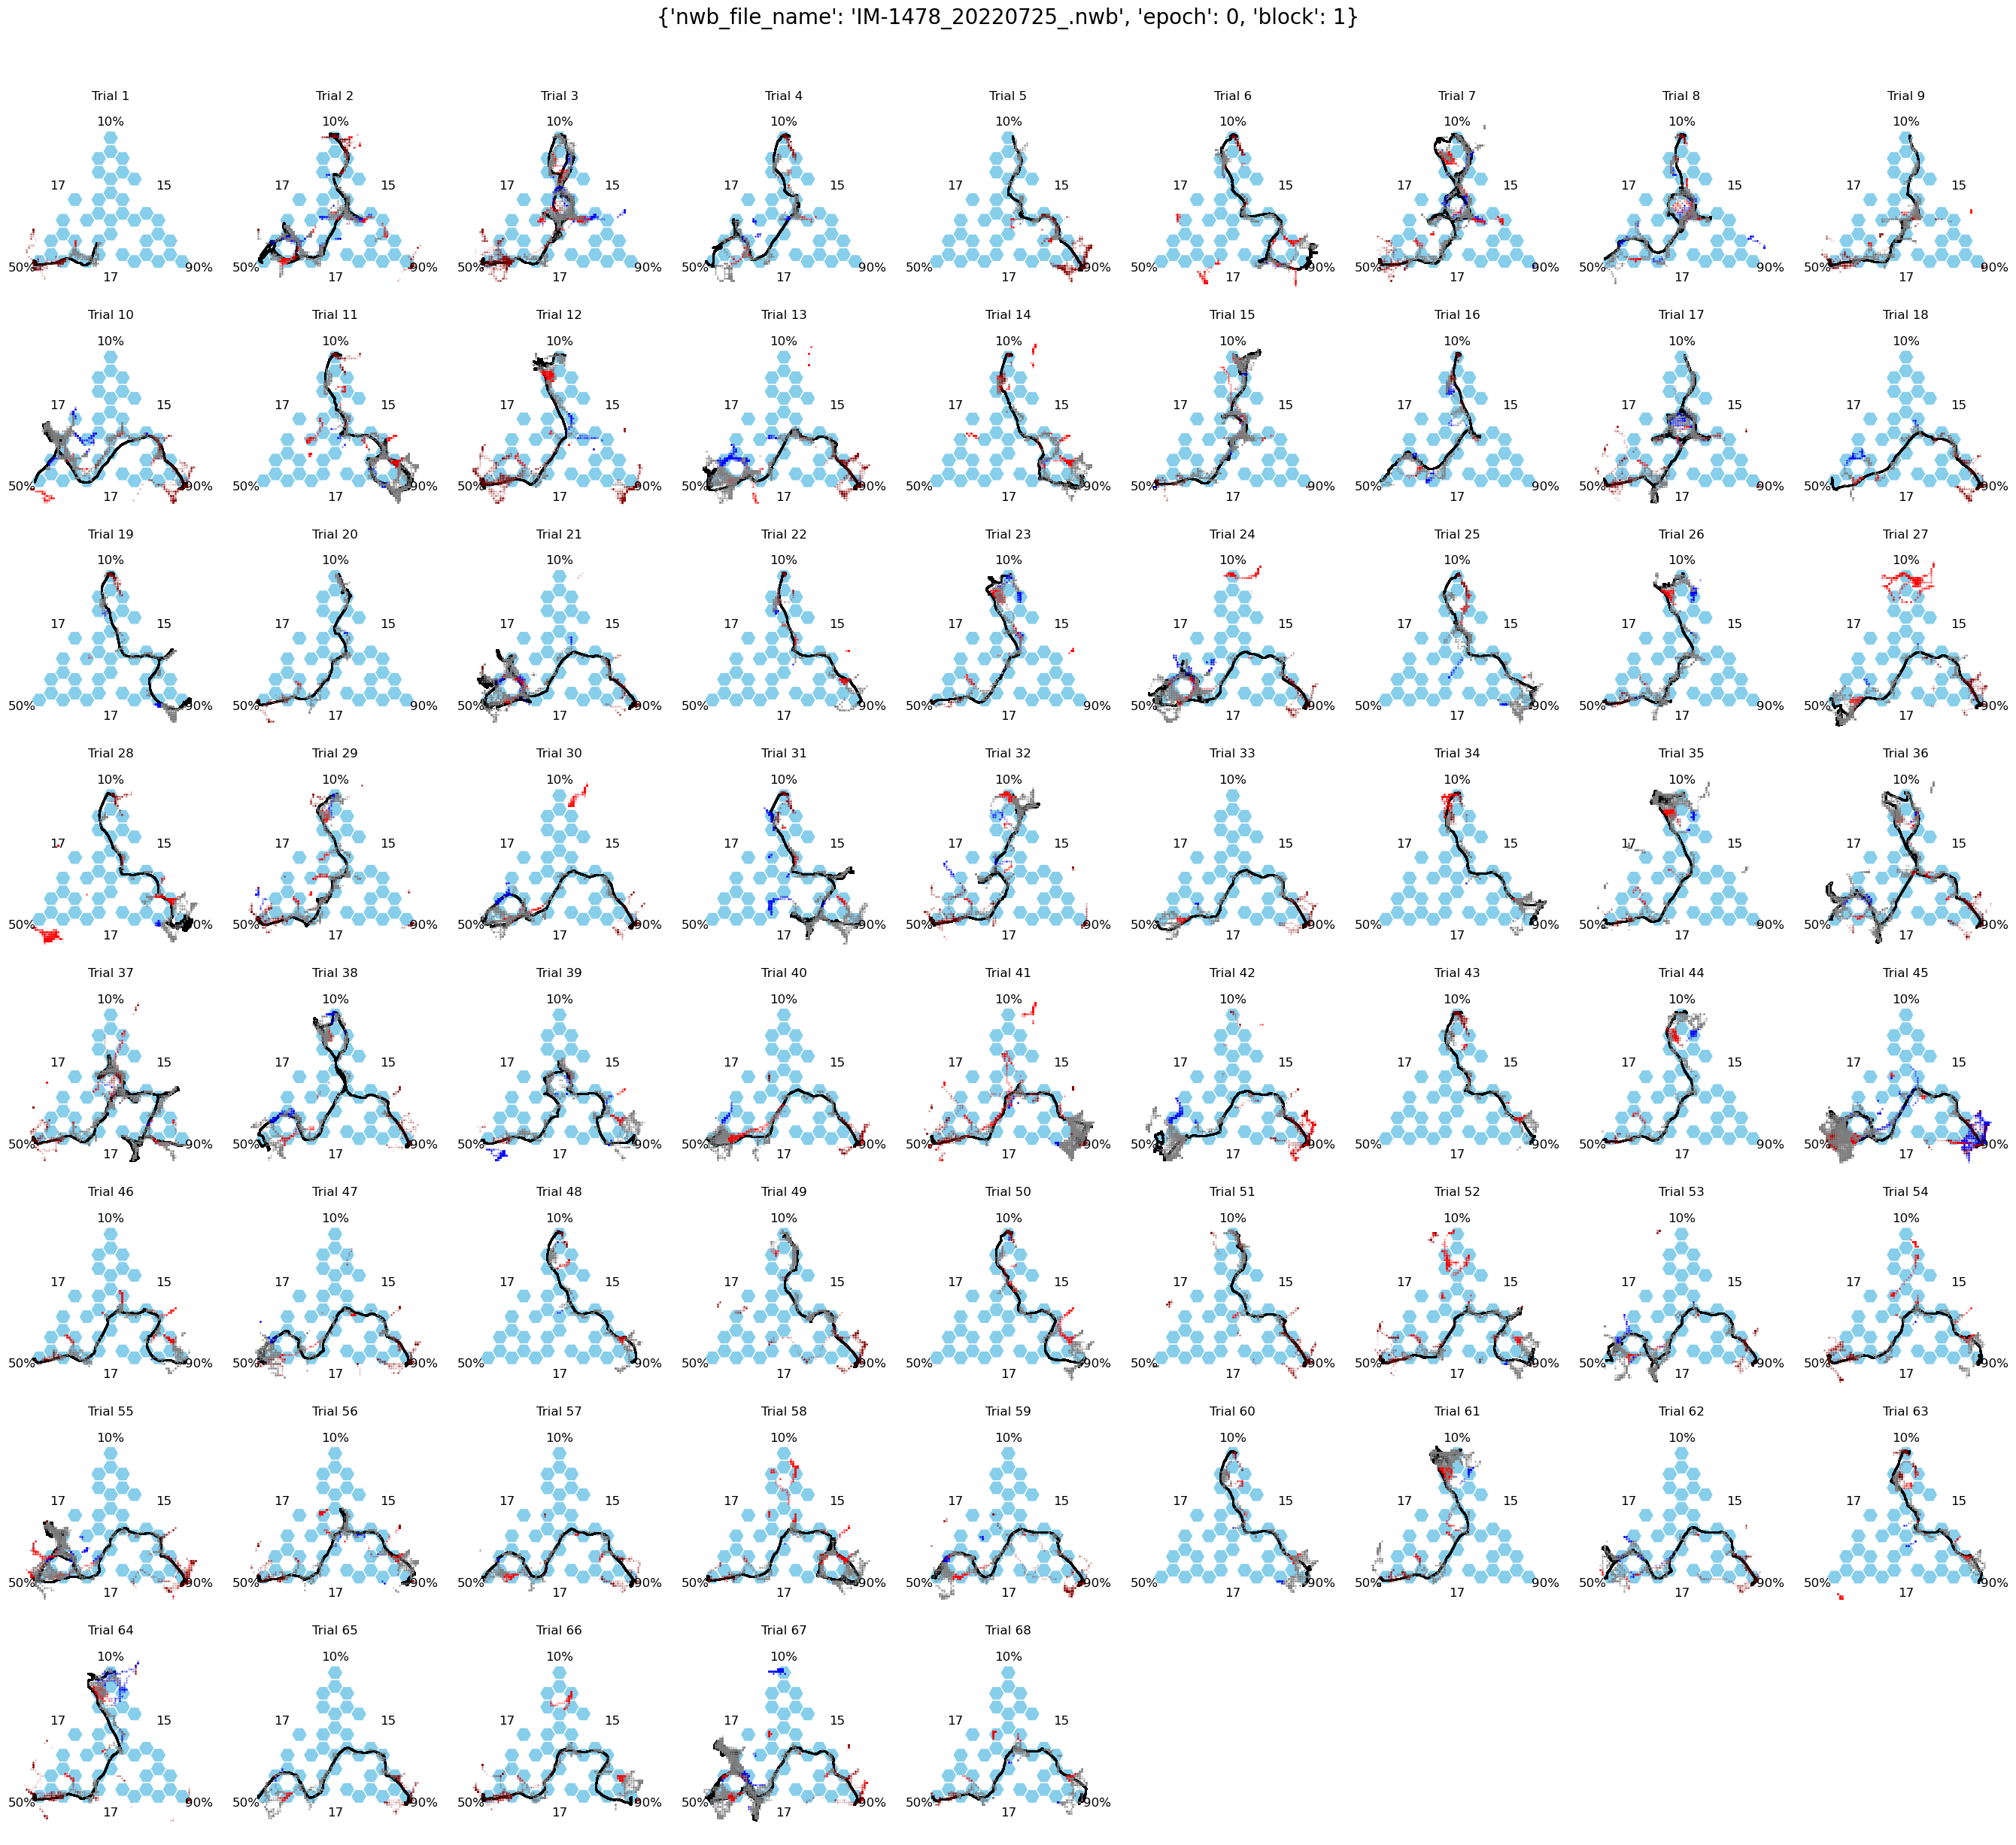

{'nwb_file_name': 'IM-1478_20220725_.nwb', 'epoch': 0, 'block': 2}: barrier change session for the hex maze task with 3 blocks and 188 trials.


[2026-04-19 13:40:41,804][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 13:40:41,814][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb


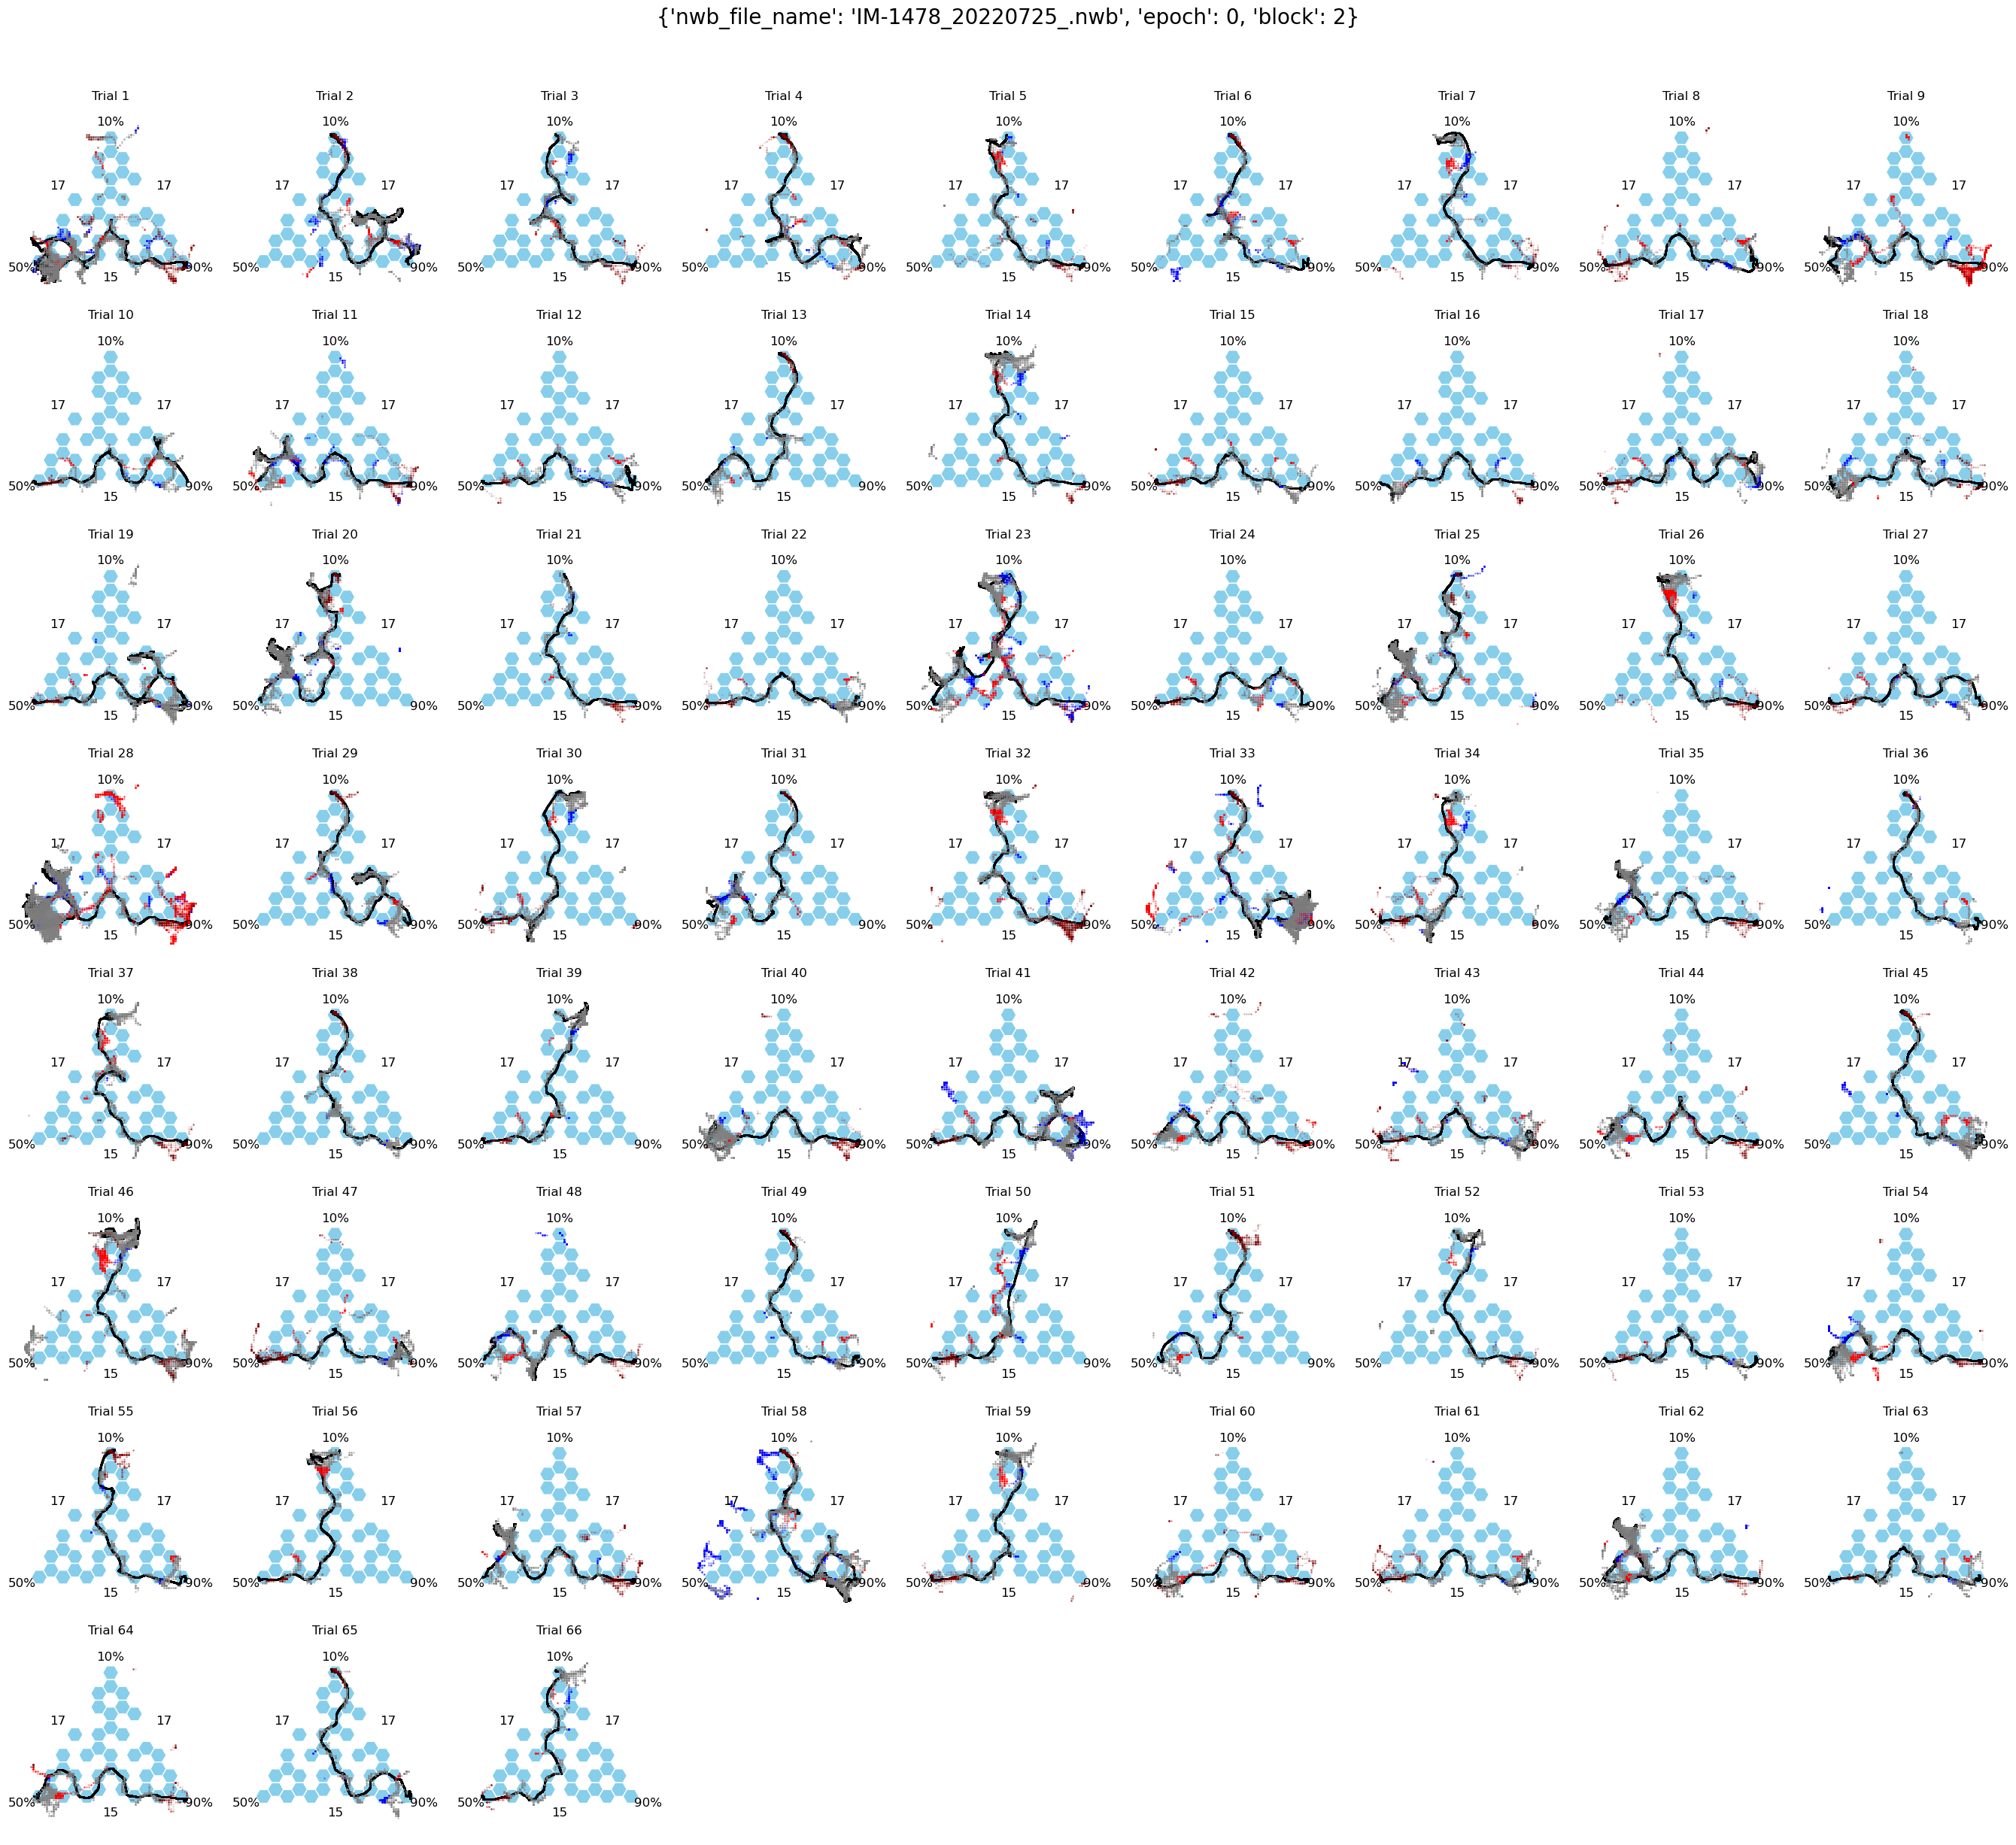

{'nwb_file_name': 'IM-1478_20220725_.nwb', 'epoch': 0, 'block': 3}: barrier change session for the hex maze task with 3 blocks and 188 trials.


[2026-04-19 13:40:58,732][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 13:40:58,741][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb


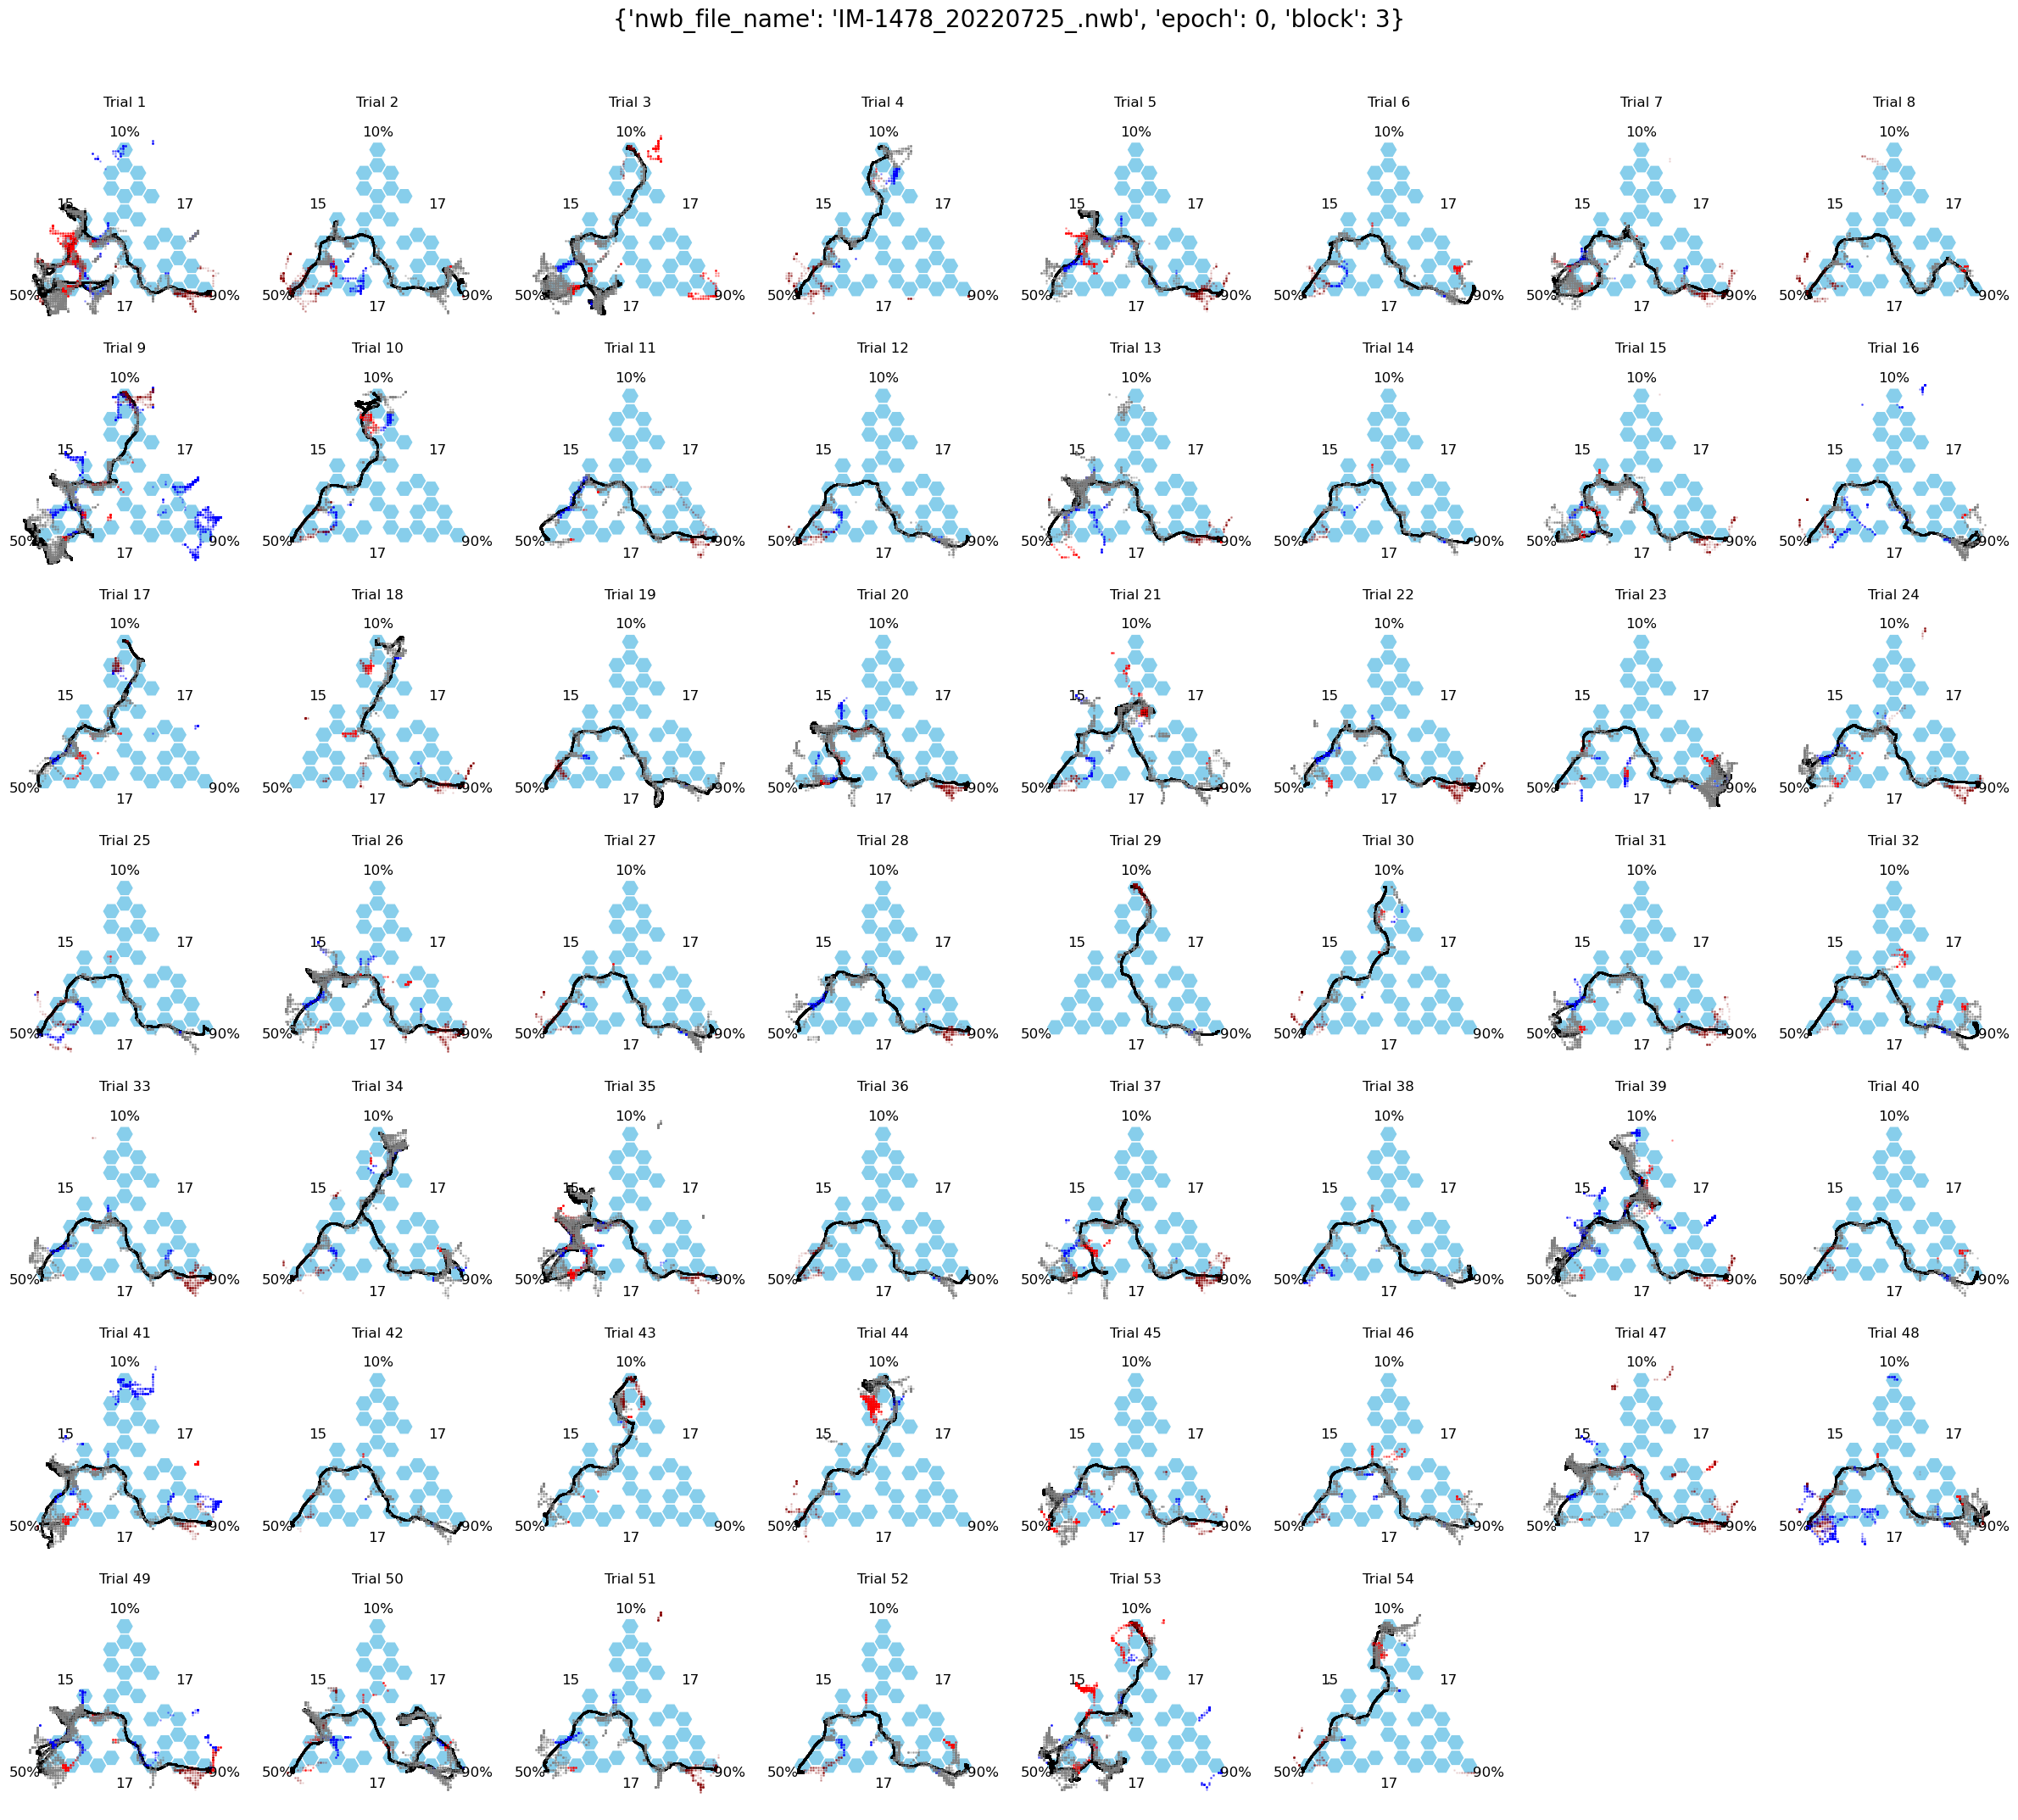

In [12]:
# Set up some restriction if you want
restriction = "nwb_file_name LIKE '%IM-1478_20220725%'" 

# Get decode keys based on restriction
decode_keys = (HexMazeJunctionDecode() & restriction).fetch("KEY", order_by="nwb_file_name, epoch")

# Only show decoded position if it meets these critera:
spatial_cov_threshold = 500 # 95% decode coverage must be less than this in cm2
speed_threshold = 2 # rat speed must be more than this in cm/s
decode_distance_threshold = 0 # decode distance from rat must be greater than this in cm

# Loop through blocks
for key in (HexMazeBlock() & decode_keys).fetch("KEY", order_by="nwb_file_name, epoch, block"):
    # Get block info
    print(f"{key}: {(sgc.Session() & key).fetch('session_description')[0]}")
    block = HexMazeBlock() & key
    trials = HexMazeBlock.Trial() & key
    num_trials = len(trials)
    maze, p_a, p_b, p_c = block.fetch1("config_id", "p_a", "p_b", "p_c")
    reward_probs = [int(p_a), int(p_b), int(p_c)]
    centroids = HexCentroids().get_core_hex_centroids_dict_cm(key)
    
    # Fetch actual and decoded position
    # (Note we would need to add decoding_merge_id to key if we have multiple entries for a nwb/epoch/block)
    pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()
    
    # Set up square-ish grid for trials
    ncols = int(np.ceil(np.sqrt(num_trials)))
    nrows = int(np.ceil(num_trials / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

    # Make sure axes is 1D so flatten doesn't break
    if isinstance(axes, plt.Axes):
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    # Big title
    fig.suptitle(f"{key}", fontsize=20, y=1.02)

    # Color map for decode junction direction
    direction_colors = {"left": "blue", "right": "red", "ambiguous": "gray"}

    # Loop over trials
    for i, trial_info in enumerate(trials):
        # Get trial start/end
        start, end = (sgc.IntervalList() & trial_info).fetch1("valid_times")[0]
        df_trial = pos_df.loc[start:end]
        
        axes[i].set_title(f"Trial {i+1}")
        plot_hex_maze(
            ax=axes[i],
            barriers=maze,
            centroids=centroids,
            snap_centroids=True,
            invert_yaxis=True,
            show_barriers=False,
            show_hex_labels=False,
            show_stats=True,
            reward_probabilities=reward_probs,
        )
            
        # Plot actual position for this trial in black
        axes[i].scatter(df_trial["position_x"], df_trial["position_y"], s=1, color='k')

        # Filter decoded position based on our criteria
        pred = df_trial[
            (df_trial["spatial_cov"] < spatial_cov_threshold) &
            (df_trial["speed"] > speed_threshold) &
            (df_trial["decode_distance"] < decode_distance_threshold)
        ]

        # Plot decoded position colored by decode junction direction
        for direction, color in direction_colors.items():
            subset = pred[pred["decode_junction_direction"] == direction]
            axes[i].scatter(subset["decode_position_x"], subset["decode_position_y"],
                            s=1, alpha=0.3, color=color, label=direction)

        # Points with no junction context in dark red
        no_junction = pred[pred["decode_junction_direction"] == "None"]
        axes[i].scatter(no_junction["decode_position_x"], no_junction["decode_position_y"],
                        s=1, alpha=0.1, color="darkred")

    # Hide unused axes
    for j in range(num_trials, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

[2026-04-19 13:49:26,950][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 13:49:26,960][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb


Junctions in this trial: [4, 7, 10, 13, 20, 25, 32, 42, 49]


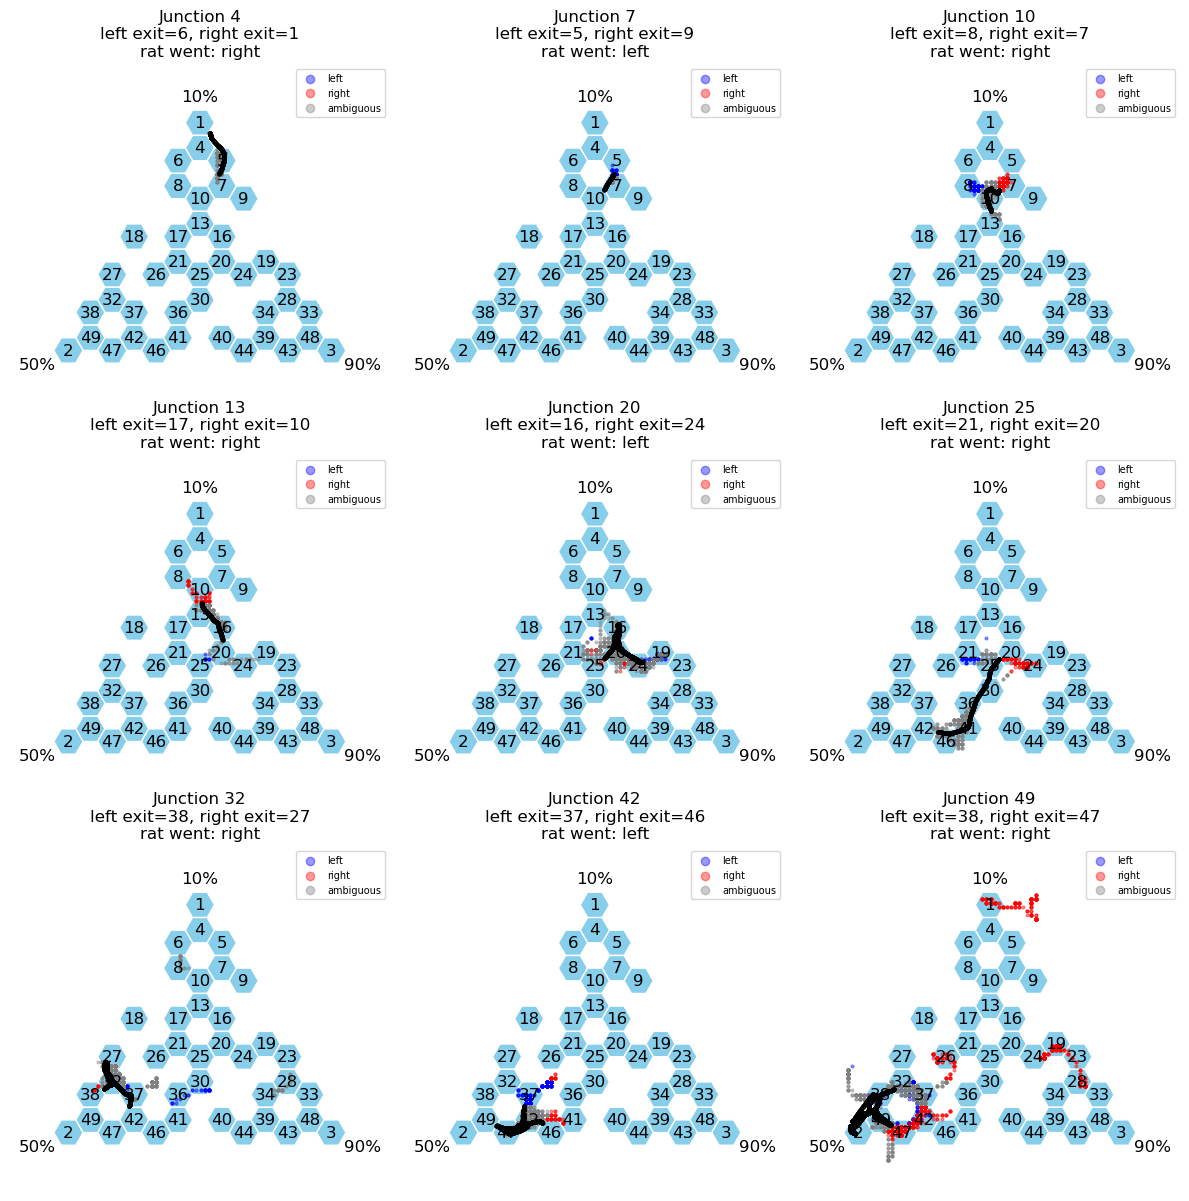

In [17]:
# Pick which block and trial to inspect
block_num = 1
trial_num = 2

key = (HexMazeJunctionDecode() & restriction).fetch("KEY")[0]
pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

block_key = (HexMazeBlock() & key & {"block": block_num}).fetch1("KEY")
maze, p_a, p_b, p_c = (HexMazeBlock() & block_key).fetch1("config_id", "p_a", "p_b", "p_c")
reward_probs = [int(p_a), int(p_b), int(p_c)]
centroids = HexCentroids().get_core_hex_centroids_dict_cm(block_key)

trial_info = (HexMazeBlock.Trial() & block_key & {"epoch_trial_num": trial_num}).fetch1()
start, end = (sgc.IntervalList() & {
    "nwb_file_name": trial_info["nwb_file_name"],
    "interval_list_name": trial_info["interval_list_name"]
}).fetch1("valid_times")[0]
df_trial = pos_df.loc[start:end]

# Get junctions that actually appear in this trial
junctions = sorted([j for j in df_trial["nearest_junction"].unique() if j != -100])
print(f"Junctions in this trial: {junctions}")

direction_colors = {"left": "blue", "right": "red", "ambiguous": "gray"}

ncols = min(3, len(junctions))
nrows = int(np.ceil(len(junctions) / ncols)) if junctions else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, junc in enumerate(junctions):
    df_junc = df_trial[df_trial["nearest_junction"] == junc]
    left_exit = df_junc["junction_left_exit"].iloc[0]
    right_exit = df_junc["junction_right_exit"].iloc[0]
    rat_dir = df_junc["rat_junction_direction"].iloc[0]

    axes[i].set_title(f"Junction {junc}\nleft exit={left_exit}, right exit={right_exit}\nrat went: {rat_dir}")
    plot_hex_maze(ax=axes[i], barriers=maze, centroids=centroids,
                  snap_centroids=True, invert_yaxis=True,
                  show_barriers=False, show_hex_labels=True,
                  show_stats=False, reward_probabilities=reward_probs)

    # Actual position in black
    axes[i].scatter(df_junc["position_x"], df_junc["position_y"], s=4, color="k", zorder=3)

    # Decoded position colored by direction
    for direction, color in direction_colors.items():
        subset = df_junc[df_junc["decode_junction_direction"] == direction]
        axes[i].scatter(subset["decode_position_x"], subset["decode_position_y"],
                        s=4, alpha=0.4, color=color, label=direction, zorder=2)

    axes[i].legend(markerscale=3, fontsize=7)

for j in range(len(junctions), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


[2026-04-19 14:04:47,858][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 14:04:47,868][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb


Junctions in trial 2: [4, 7, 10, 13, 20, 25, 32, 42, 49]


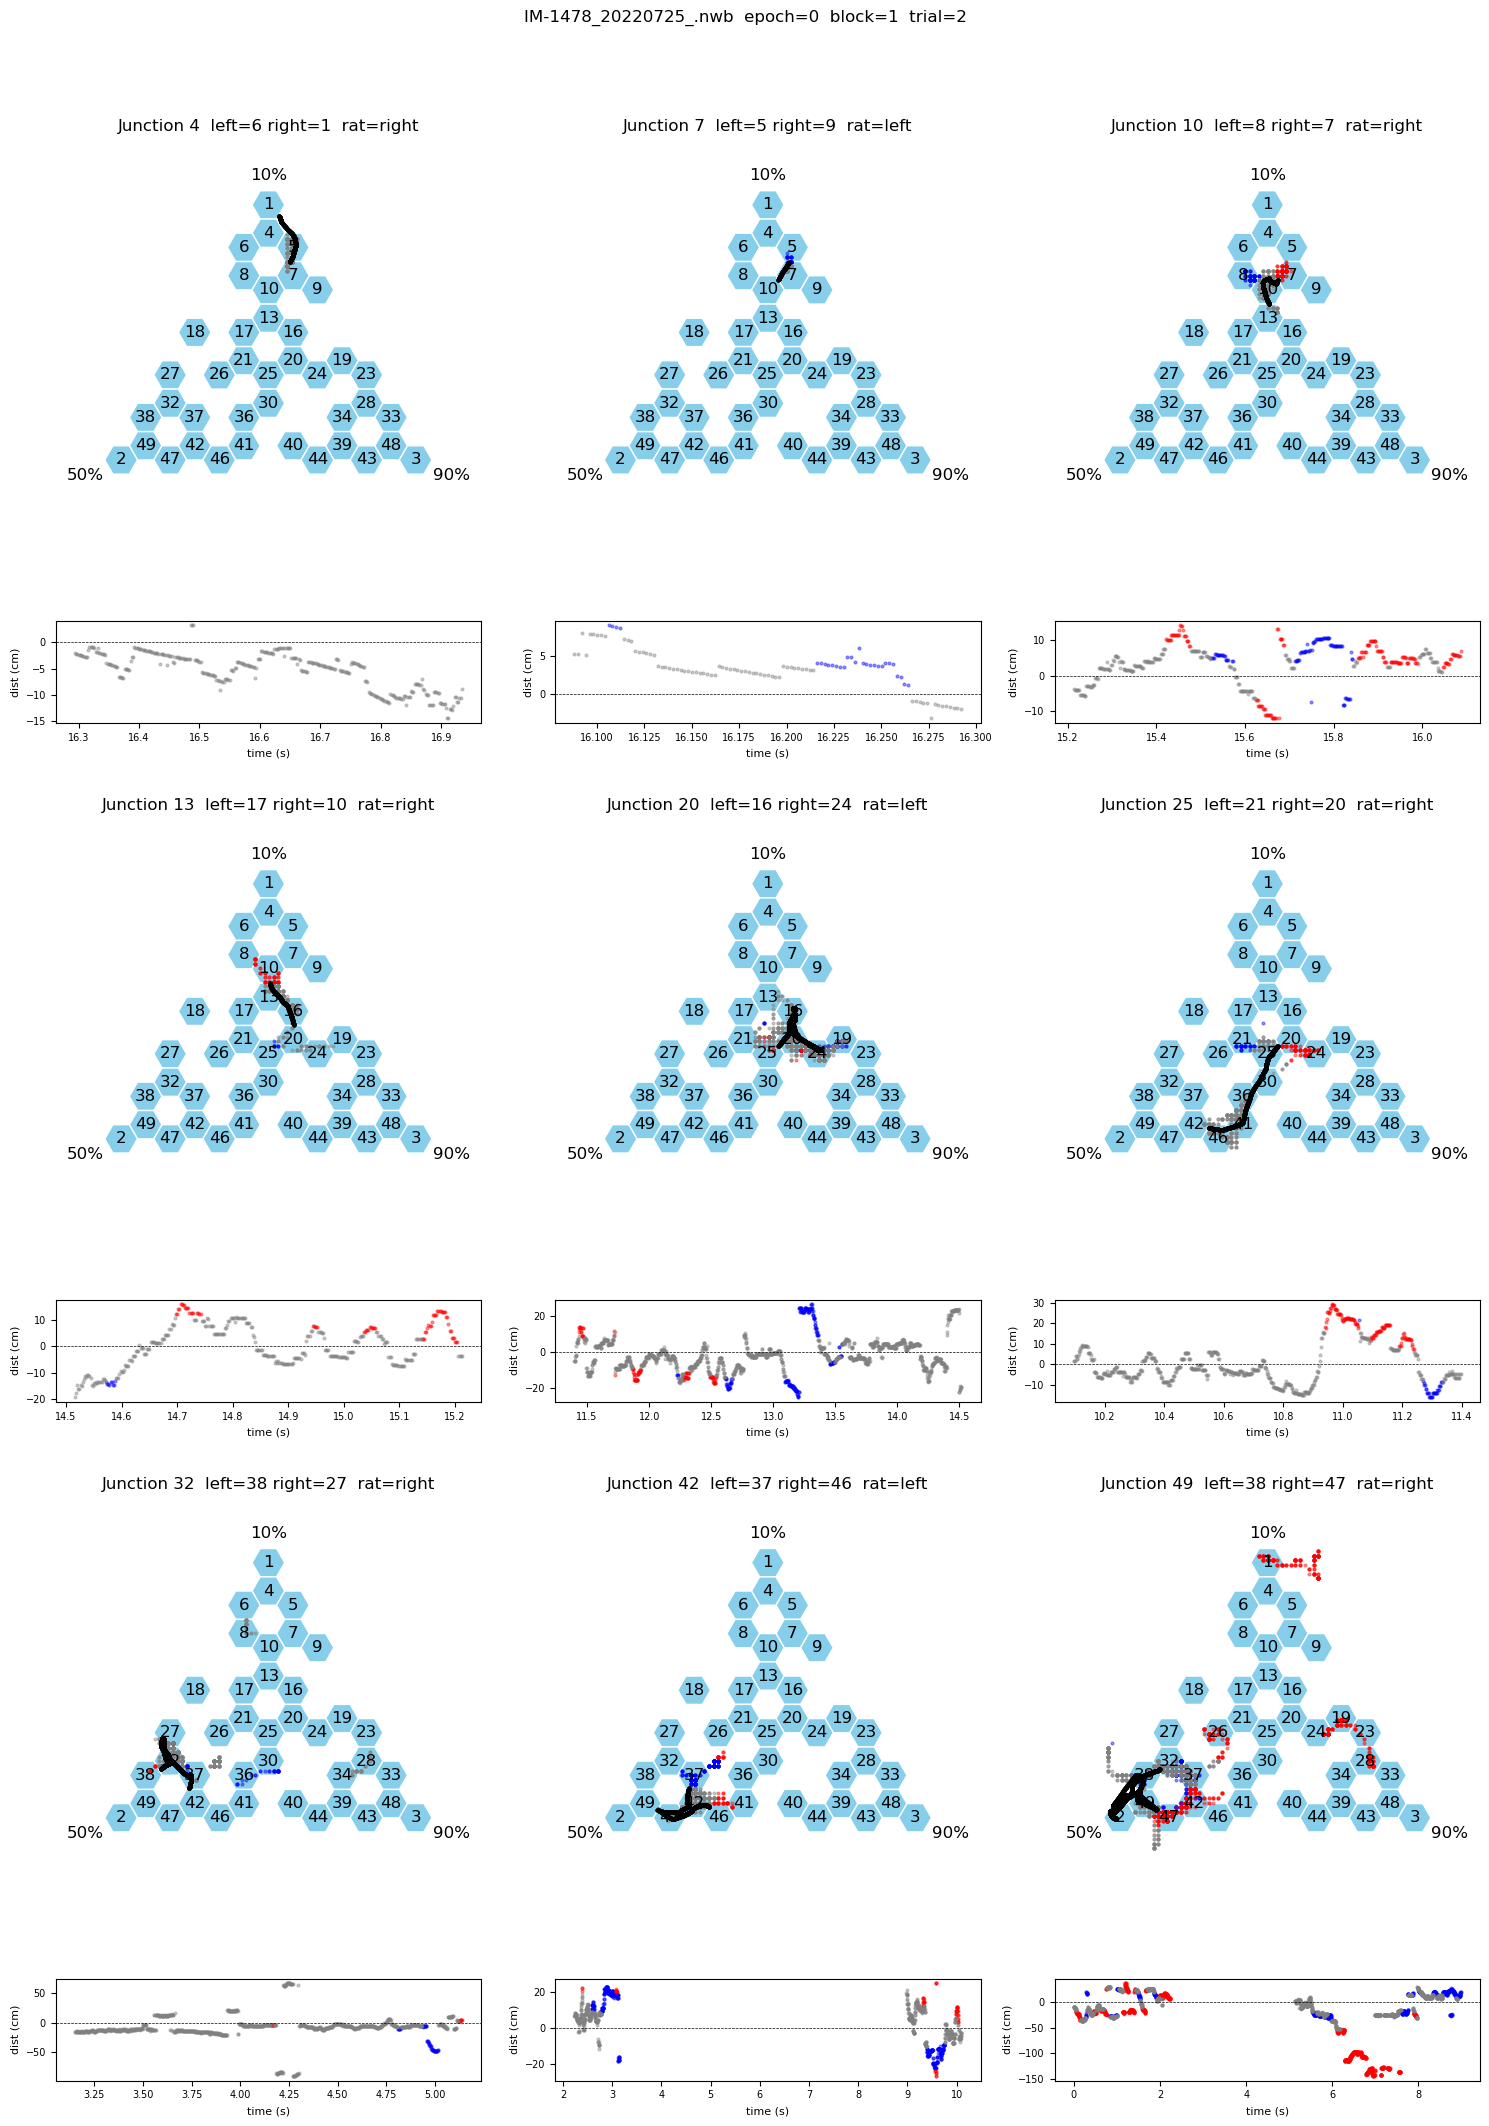

In [22]:
# ---- Configure which session, block, and trial to inspect ----
restriction = "nwb_file_name LIKE '%IM-1478_20220725%'"
block_num = 1
trial_num = 2

# ---- Fetch data ----
key = (HexMazeJunctionDecode() & restriction).fetch("KEY")[0]
pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

block_key = (HexMazeBlock() & key & {"block": block_num}).fetch1("KEY")
maze, p_a, p_b, p_c = (HexMazeBlock() & block_key).fetch1("config_id", "p_a", "p_b", "p_c")
reward_probs = [int(p_a), int(p_b), int(p_c)]
centroids = HexCentroids().get_core_hex_centroids_dict_cm(block_key)

trial_info = (HexMazeBlock.Trial() & block_key & {"epoch_trial_num": trial_num}).fetch1()
start, end = (sgc.IntervalList() & {
    "nwb_file_name": trial_info["nwb_file_name"],
    "interval_list_name": trial_info["interval_list_name"]
}).fetch1("valid_times")[0]
df_trial = pos_df.loc[start:end]

# ---- Get junctions visited in this trial ----
junctions = sorted([j for j in df_trial["nearest_junction"].unique() if j != -100])
print(f"Junctions in trial {trial_num}: {junctions}")

direction_colors = {"left": "blue", "right": "red", "ambiguous": "gray"}

# ---- Layout: tall maze on top, short distance plot on bottom ----
ncols = min(3, len(junctions))
maze_rows = int(np.ceil(len(junctions) / ncols))
nrows = maze_rows * 2
height_ratios = [5, 1] * maze_rows  # maze much taller than distance plot

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 7 * maze_rows),
                          gridspec_kw={"height_ratios": height_ratios})
axes = np.array(axes).reshape(nrows, ncols)

for i, junc in enumerate(junctions):
    col = i % ncols
    maze_row = (i // ncols) * 2
    dist_row = maze_row + 1

    ax_maze = axes[maze_row, col]
    ax_dist = axes[dist_row, col]

    df_junc = df_trial[df_trial["nearest_junction"] == junc]
    left_exit = df_junc["junction_left_exit"].iloc[0]
    right_exit = df_junc["junction_right_exit"].iloc[0]
    rat_dir = df_junc["rat_junction_direction"].iloc[0]

    ax_maze.set_title(f"Junction {junc}  left={left_exit} right={right_exit}  rat={rat_dir}")
    plot_hex_maze(ax=ax_maze, barriers=maze, centroids=centroids,
                  snap_centroids=True, invert_yaxis=True,
                  show_barriers=False, show_hex_labels=True,
                  show_stats=False, reward_probabilities=reward_probs)

    # Actual position in black
    ax_maze.scatter(df_junc["position_x"], df_junc["position_y"], s=4, color="k", zorder=3)

    # Decoded position + decode_distance colored by direction
    for direction, color in direction_colors.items():
        subset = df_junc[df_junc["decode_junction_direction"] == direction]
        ax_maze.scatter(subset["decode_position_x"], subset["decode_position_y"],
                        s=4, alpha=0.4, color=color, zorder=2)
        ax_dist.scatter(subset.index - start, subset["decode_distance"],
                        s=4, alpha=0.4, color=color)

    no_junc = df_junc[df_junc["decode_junction_direction"] == "None"]
    ax_maze.scatter(no_junc["decode_position_x"], no_junc["decode_position_y"],
                    s=4, alpha=0.1, color="darkred")
    ax_dist.scatter(no_junc.index - start, no_junc["decode_distance"],
                    s=4, alpha=0.1, color="darkred")

    ax_dist.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax_dist.set_xlabel("time (s)", fontsize=8)
    ax_dist.set_ylabel("dist (cm)", fontsize=8)
    ax_dist.tick_params(labelsize=7)

# Hide unused panels
for i in range(len(junctions), maze_rows * ncols):
    col = i % ncols
    maze_row = (i // ncols) * 2
    axes[maze_row, col].axis("off")
    axes[maze_row + 1, col].axis("off")

fig.suptitle(f"{key['nwb_file_name']}  epoch={key['epoch']}  block={block_num}  trial={trial_num}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


[2026-04-19 17:46:25,691][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
[2026-04-19 17:46:25,698][WARNING]: Skipped checksum for file with hash: a37de03f-c559-b857-907e-27045ad9f5ef, and path: /stelmo/nwb/analysis/IM-1478_20220725/IM-1478_20220725_E5C1F1A30P.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

Junction visits in trial 4: [48, 28, 39, 30, 30, 21, 13, 10, 7, 4]


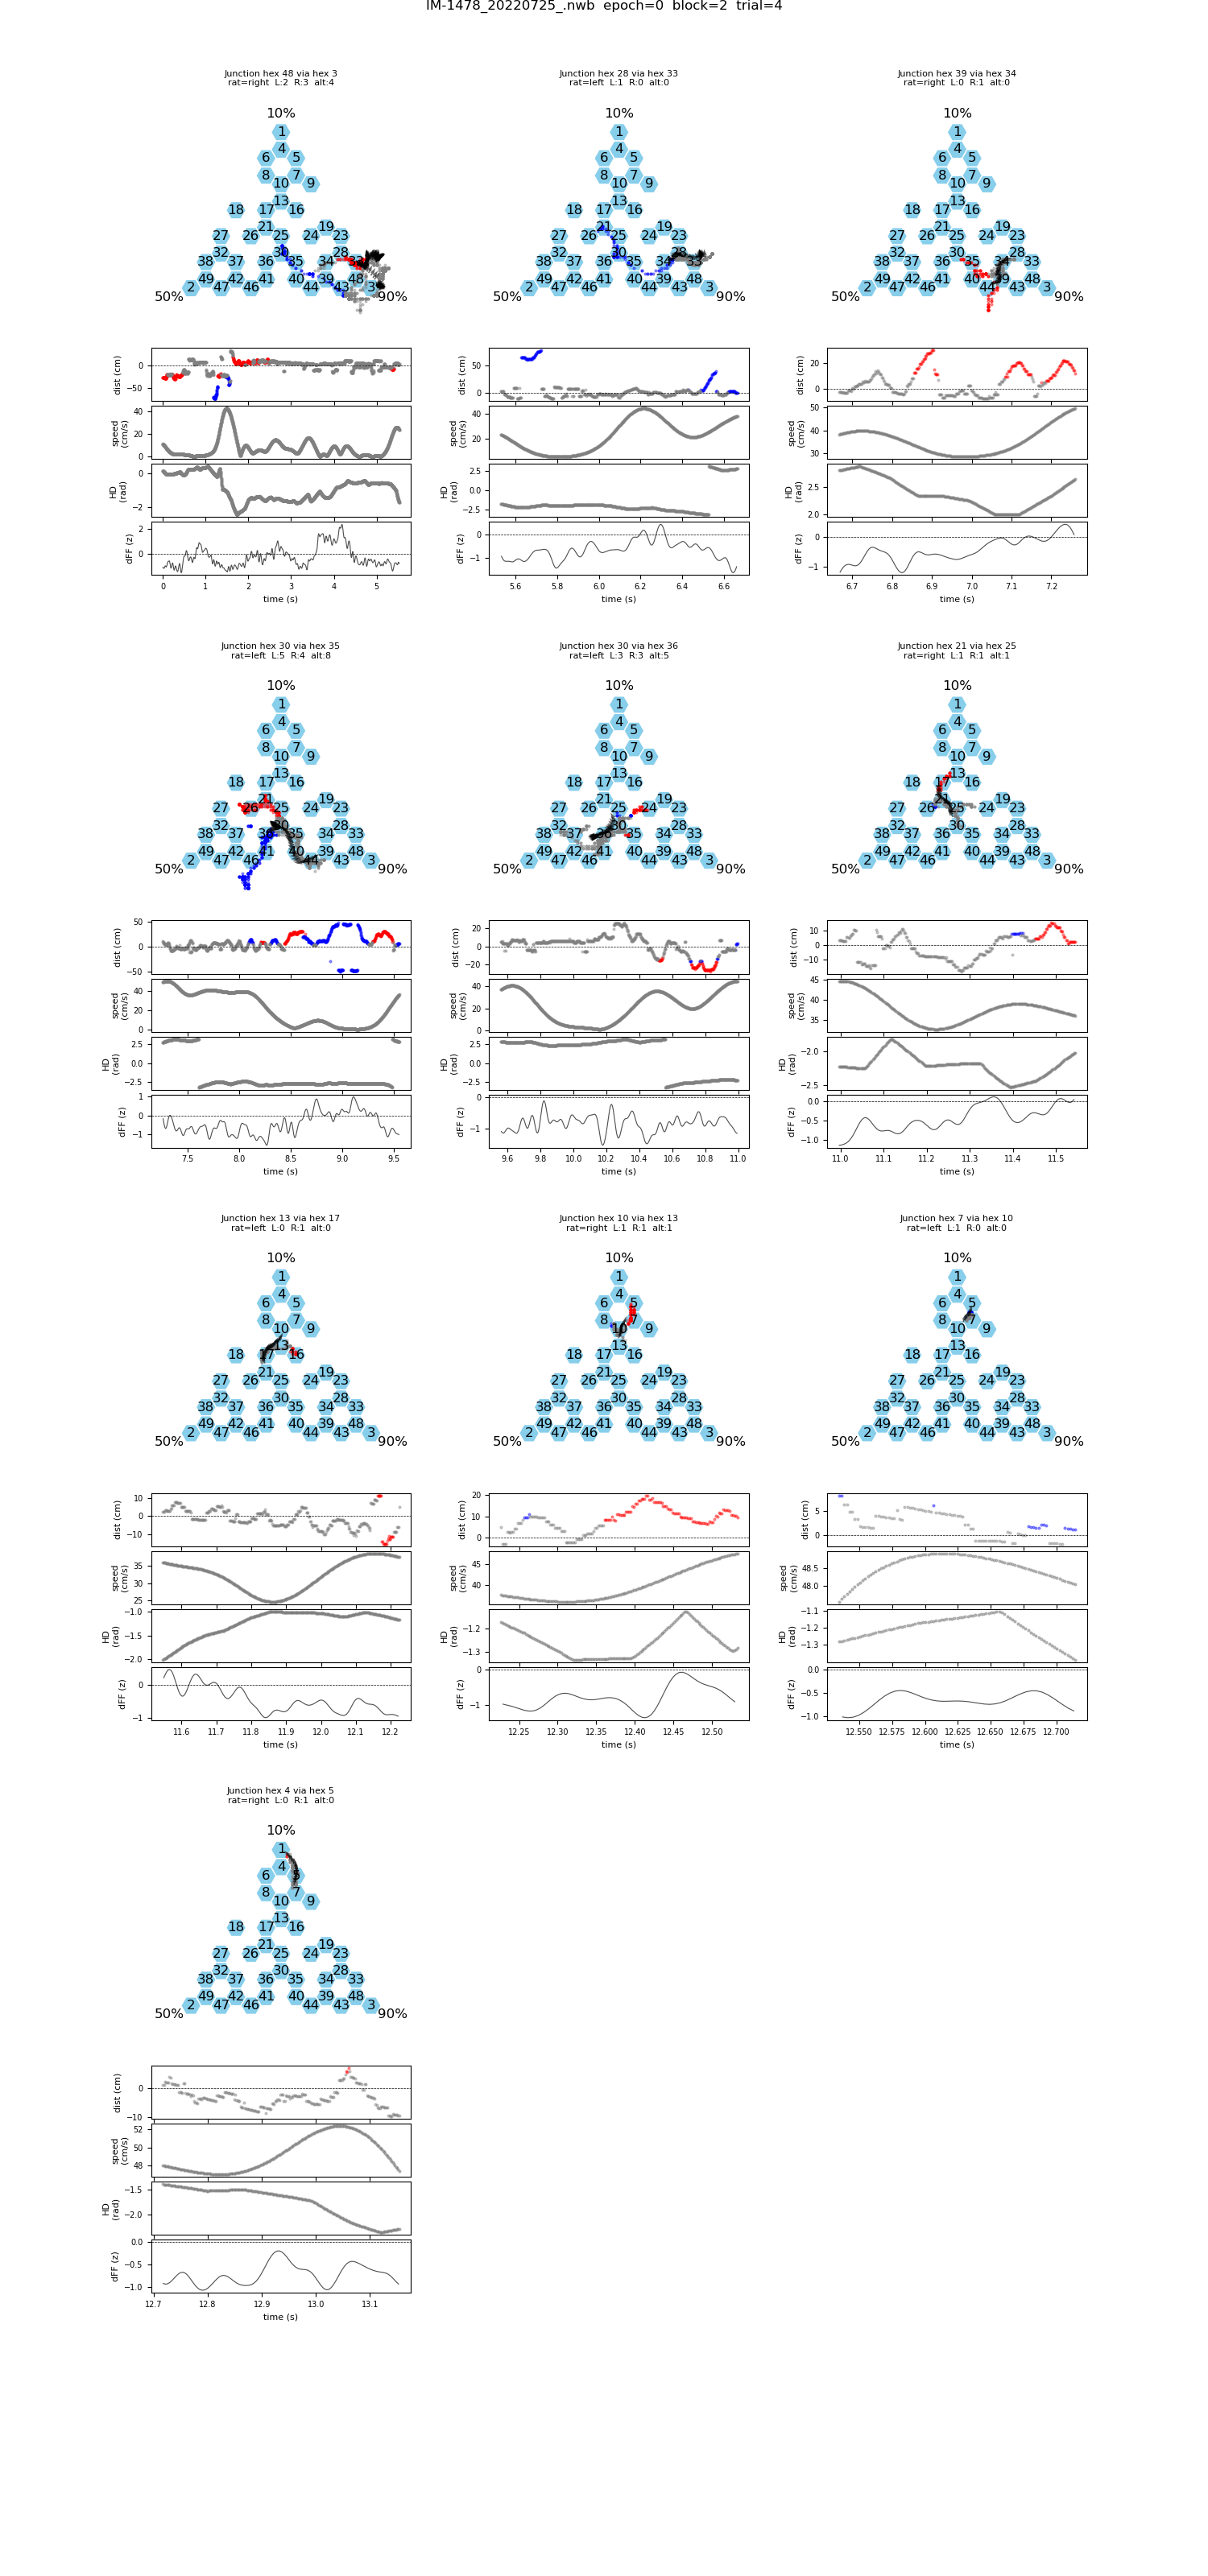

In [ ]:
%matplotlib widget

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from pynwb import NWBHDF5IO
from spyglass.common import Nwbfile

restriction = "nwb_file_name LIKE '%IM-1478_20220725%'"
block_num = 2
trial_num = 4
name_of_DA_trace = "z_scored_green_dFF"

# Fetch
key = (HexMazeJunctionDecode() & restriction).fetch("KEY")[0]
pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

block_key = (HexMazeBlock() & key & {"block": block_num}).fetch1("KEY")
maze, p_a, p_b, p_c = (HexMazeBlock() & block_key).fetch1("config_id", "p_a", "p_b", "p_c")
reward_probs = [int(p_a), int(p_b), int(p_c)]
centroids = HexCentroids().get_core_hex_centroids_dict_cm(block_key)

trial_info = (HexMazeBlock.Trial() & block_key & {"block_trial_num": trial_num}).fetch1()
start, end = (sgc.IntervalList() & {
    "nwb_file_name": trial_info["nwb_file_name"],
    "interval_list_name": trial_info["interval_list_name"]
}).fetch1("valid_times")[0]
df_trial = pos_df.loc[start:end]

# Load DA trace
nwb_path = Nwbfile().get_abs_path(key["nwb_file_name"])
with NWBHDF5IO(nwb_path, mode="r") as io:
    nwbfile = io.read()
    DA_object = nwbfile.acquisition[name_of_DA_trace]
    DA_trace = DA_object.data[:]
    DA_timestamps = DA_object.get_timestamps()
DA_series = pd.Series(DA_trace, index=DA_timestamps)

# Get ordered junction visits, splitting on entry direction changes
junc_entry_series = pd.Series(
    list(zip(df_trial["nearest_junction"], df_trial["junction_entry_hex"])),
    index=df_trial.index
)
run_ids = (junc_entry_series != junc_entry_series.shift()).cumsum()
visits = []
for _, group in df_trial.groupby(run_ids, sort=False):
    junc = group["nearest_junction"].iloc[0]
    if junc != -100:
        visits.append((junc, group.index[0], group.index[-1]))

print(f"Junction visits in trial {trial_num}: {[j for j, _, _ in visits]}")

direction_colors = {"left": "blue", "right": "red", "ambiguous": "gray"}

# Nested GridSpec: tight hspace between groups, tighter within
ncols = min(3, len(visits))
maze_rows = int(np.ceil(len(visits) / ncols))

fig = plt.figure(figsize=(5 * ncols, 8 * maze_rows))
outer = GridSpec(maze_rows, ncols, figure=fig, hspace=0.15, wspace=0.3)

for i, (junc, t_start, t_end) in enumerate(visits):
    row = i // ncols
    col = i % ncols

    inner = GridSpecFromSubplotSpec(5, 1, subplot_spec=outer[row, col],
                                    height_ratios=[5, 1, 1, 1, 1], hspace=0.05)
    ax_maze  = fig.add_subplot(inner[0])
    ax_dist  = fig.add_subplot(inner[1])
    ax_speed = fig.add_subplot(inner[2], sharex=ax_dist)
    ax_hd    = fig.add_subplot(inner[3], sharex=ax_dist)
    ax_da    = fig.add_subplot(inner[4], sharex=ax_dist)

    df_junc = df_trial.loc[t_start:t_end]
    entry_hex = df_junc["junction_entry_hex"].iloc[0]
    left_exit = df_junc["junction_left_exit"].iloc[0]
    right_exit = df_junc["junction_right_exit"].iloc[0]
    rat_dir = df_junc["rat_junction_direction"].iloc[0]

    # Compute decode entry counts and alternations
    lr_only = df_junc["decode_junction_direction"][df_junc["decode_junction_direction"].isin(["left", "right"])]
    lr_runs = lr_only[lr_only != lr_only.shift()]
    n_left_entries = (lr_runs == "left").sum()
    n_right_entries = (lr_runs == "right").sum()
    n_alternations = max(0, len(lr_runs) - 1)

    ax_maze.set_title(
        f"Junction hex {junc} via hex {entry_hex}\n"
        f"rat={rat_dir}  L:{n_left_entries}  R:{n_right_entries}  alt:{n_alternations}",
        fontsize=8
    )
    plot_hex_maze(ax=ax_maze, barriers=maze, centroids=centroids,
                  snap_centroids=True, invert_yaxis=True,
                  show_barriers=False, show_hex_labels=True,
                  show_stats=False, reward_probabilities=reward_probs)

    # Decoded position colored by direction
    for direction, color in direction_colors.items():
        subset = df_junc[df_junc["decode_junction_direction"] == direction]
        ax_maze.scatter(subset["decode_position_x"], subset["decode_position_y"],
                        s=4, alpha=0.4, color=color, zorder=2)
        ax_dist.scatter(subset.index - start, subset["decode_distance"],
                        s=4, alpha=0.4, color=color)

    no_junc = df_junc[df_junc["decode_junction_direction"] == "None"]
    ax_maze.scatter(no_junc["decode_position_x"], no_junc["decode_position_y"],
                    s=4, alpha=0.1, color="darkred")
    ax_dist.scatter(no_junc.index - start, no_junc["decode_distance"],
                    s=4, alpha=0.1, color="darkred")

    # Actual position with subsampled orientation arrows
    stride = 20
    df_sub = df_junc.iloc[::stride]
    ax_maze.quiver(
        df_sub["position_x"], df_sub["position_y"],
        np.cos(df_sub["orientation"]), -np.sin(df_sub["orientation"]),
        color="k", alpha=0.6, scale=30, width=0.005, zorder=3
    )

    # Speed (grey)
    ax_speed.scatter(df_junc.index - start, df_junc["speed"],
                     s=4, alpha=0.5, color="gray")

    # Head direction
    ax_hd.scatter(df_junc.index - start, df_junc["orientation"],
                  s=4, alpha=0.5, color="gray")

    # DA trace
    da_window = DA_series.loc[t_start:t_end]
    ax_da.plot(da_window.index - start, da_window.values,
               color="k", linewidth=0.8, alpha=0.7)
    ax_da.axhline(0, color="k", linewidth=0.5, linestyle="--")

    ax_dist.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax_dist.set_ylabel("dist (cm)", fontsize=8)
    ax_dist.tick_params(labelsize=7)
    plt.setp(ax_dist.get_xticklabels(), visible=False)

    ax_speed.set_ylabel("speed\n(cm/s)", fontsize=8)
    ax_speed.tick_params(labelsize=7)
    plt.setp(ax_speed.get_xticklabels(), visible=False)

    ax_hd.set_ylabel("HD\n(rad)", fontsize=8)
    ax_hd.tick_params(labelsize=7)
    plt.setp(ax_hd.get_xticklabels(), visible=False)

    ax_da.set_xlabel("time (s)", fontsize=8)
    ax_da.set_ylabel("dFF (z)", fontsize=8)
    ax_da.tick_params(labelsize=7)

fig.suptitle(f"{key['nwb_file_name']}  epoch={key['epoch']}  block={block_num}  trial={trial_num}",
             fontsize=12, y=1.0)
plt.subplots_adjust(top=0.97)
plt.show()


In [ ]:
%matplotlib widget

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

restriction = "nwb_file_name LIKE '%IM-1478_20220725%'"
block_num = 1
trial_num = 1

# Fetch
key = (HexMazeJunctionDecode() & restriction).fetch("KEY")[0]
pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

block_key = (HexMazeBlock() & key & {"block": block_num}).fetch1("KEY")
maze, p_a, p_b, p_c = (HexMazeBlock() & block_key).fetch1("config_id", "p_a", "p_b", "p_c")
reward_probs = [int(p_a), int(p_b), int(p_c)]
centroids = HexCentroids().get_core_hex_centroids_dict_cm(block_key)

trial_info = (HexMazeBlock.Trial() & block_key & {"epoch_trial_num": trial_num}).fetch1()
start, end = (sgc.IntervalList() & {
    "nwb_file_name": trial_info["nwb_file_name"],
    "interval_list_name": trial_info["interval_list_name"]
}).fetch1("valid_times")[0]
df_trial = pos_df.loc[start:end]

# Get ordered junction visits, splitting on entry direction changes
junc_entry_series = pd.Series(
    list(zip(df_trial["nearest_junction"], df_trial["junction_entry_hex"])),
    index=df_trial.index
)
run_ids = (junc_entry_series != junc_entry_series.shift()).cumsum()
visits = []
for _, group in df_trial.groupby(run_ids, sort=False):
    junc = group["nearest_junction"].iloc[0]
    if junc != -100:
        visits.append((junc, group.index[0], group.index[-1]))

print(f"Junction visits in trial {trial_num}: {[j for j, _, _ in visits]}")

direction_colors = {"left": "blue", "right": "red", "ambiguous": "gray"}

# Nested GridSpec: tight hspace between groups, tighter within
ncols = min(3, len(visits))
maze_rows = int(np.ceil(len(visits) / ncols))

fig = plt.figure(figsize=(5 * ncols, 8 * maze_rows))
outer = GridSpec(maze_rows, ncols, figure=fig, hspace=0.15, wspace=0.3)

for i, (junc, t_start, t_end) in enumerate(visits):
    row = i // ncols
    col = i % ncols

    inner = GridSpecFromSubplotSpec(4, 1, subplot_spec=outer[row, col],
                                    height_ratios=[5, 1, 1, 1], hspace=0.05)
    ax_maze  = fig.add_subplot(inner[0])
    ax_dist  = fig.add_subplot(inner[1])
    ax_speed = fig.add_subplot(inner[2], sharex=ax_dist)
    ax_hd    = fig.add_subplot(inner[3], sharex=ax_dist)

    df_junc = df_trial.loc[t_start:t_end]
    entry_hex = df_junc["junction_entry_hex"].iloc[0]
    left_exit = df_junc["junction_left_exit"].iloc[0]
    right_exit = df_junc["junction_right_exit"].iloc[0]
    rat_dir = df_junc["rat_junction_direction"].iloc[0]

    # Compute decode entry counts and alternations
    lr_only = df_junc["decode_junction_direction"][df_junc["decode_junction_direction"].isin(["left", "right"])]
    lr_runs = lr_only[lr_only != lr_only.shift()]
    n_left_entries = (lr_runs == "left").sum()
    n_right_entries = (lr_runs == "right").sum()
    n_alternations = max(0, len(lr_runs) - 1)

    ax_maze.set_title(
        f"Visit {i+1}: junction {junc} via {entry_hex}\n"
        f"rat={rat_dir}  L:{n_left_entries}  R:{n_right_entries}  alt:{n_alternations}",
        fontsize=8
    )
    plot_hex_maze(ax=ax_maze, barriers=maze, centroids=centroids,
                  snap_centroids=True, invert_yaxis=True,
                  show_barriers=False, show_hex_labels=True,
                  show_stats=False, reward_probabilities=reward_probs)

    # Decoded position colored by direction
    for direction, color in direction_colors.items():
        subset = df_junc[df_junc["decode_junction_direction"] == direction]
        ax_maze.scatter(subset["decode_position_x"], subset["decode_position_y"],
                        s=4, alpha=0.4, color=color, zorder=2)
        ax_dist.scatter(subset.index - start, subset["decode_distance"],
                        s=4, alpha=0.4, color=color)

    no_junc = df_junc[df_junc["decode_junction_direction"] == "None"]
    ax_maze.scatter(no_junc["decode_position_x"], no_junc["decode_position_y"],
                    s=4, alpha=0.1, color="darkred")
    ax_dist.scatter(no_junc.index - start, no_junc["decode_distance"],
                    s=4, alpha=0.1, color="darkred")

    # Actual position with subsampled orientation arrows
    stride = 5
    df_sub = df_junc.iloc[::stride]
    ax_maze.quiver(
        df_sub["position_x"], df_sub["position_y"],
        np.cos(df_sub["orientation"]), -np.sin(df_sub["orientation"]),
        color="k", alpha=0.6, scale=30, width=0.005, zorder=3
    )

    # Speed (grey)
    ax_speed.scatter(df_junc.index - start, df_junc["speed"],
                     s=4, alpha=0.5, color="gray")

    # Head direction
    ax_hd.scatter(df_junc.index - start, df_junc["orientation"],
                  s=4, alpha=0.5, color="gray")

    ax_dist.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax_dist.set_ylabel("dist (cm)", fontsize=8)
    ax_dist.tick_params(labelsize=7)
    plt.setp(ax_dist.get_xticklabels(), visible=False)

    ax_speed.set_ylabel("speed\n(cm/s)", fontsize=8)
    ax_speed.tick_params(labelsize=7)
    plt.setp(ax_speed.get_xticklabels(), visible=False)

    ax_hd.set_xlabel("time (s)", fontsize=8)
    ax_hd.set_ylabel("HD\n(rad)", fontsize=8)
    ax_hd.tick_params(labelsize=7)

fig.suptitle(f"{key['nwb_file_name']}  epoch={key['epoch']}  block={block_num}  trial={trial_num}",
             fontsize=12, y=1.0)
plt.subplots_adjust(top=0.97)
plt.show()


## Decode prediction accuracy at junctions

When the rat is at a junction, does the decode point toward the side the rat will choose?

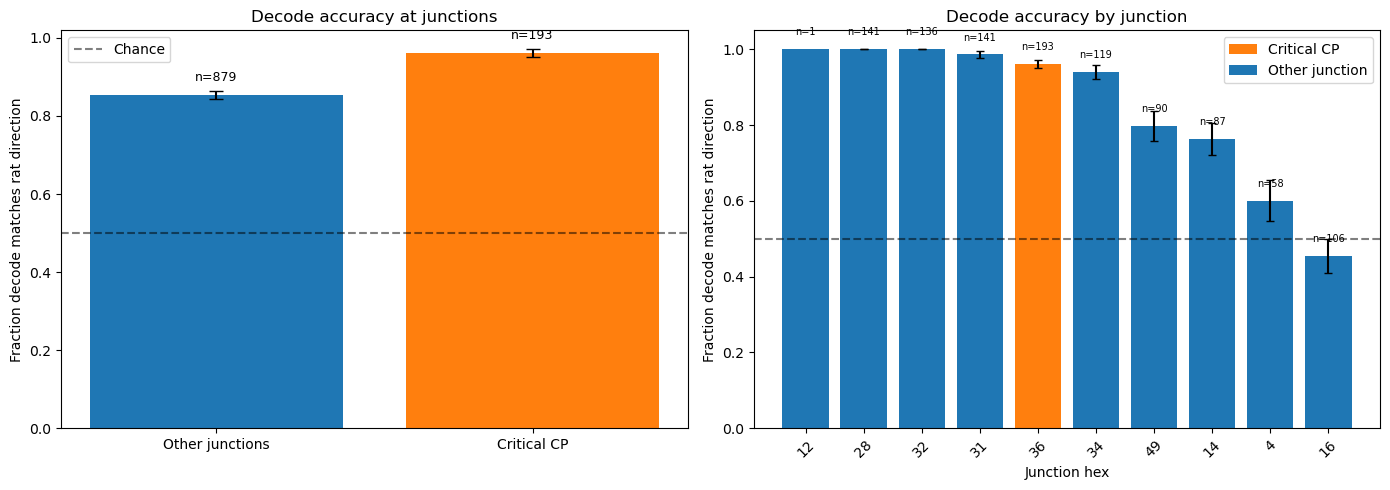

In [3]:
# Filter to high-confidence timepoints at junctions
# Each row is one decoded timepoint while the rat is on the junction hex.
# We require low spatial covariance (tight posterior), sufficient speed
# (not stationary), and valid left/right labels for both rat and decode.
filtered = df[
    (df["spatial_cov"] < 500)
    & (df["speed"] > 5)
    & (df["hexes_from_junction"] == 0)
    & (df["rat_junction_direction"].isin(["left", "right"]))
    & (df["decode_junction_direction"].isin(["left", "right"]))
    & (df["epoch_trial_num"] > 1)
]

# For each timepoint, check whether the decoded direction matches the
# direction the rat actually chose. The decode can fluctuate between
# left and right within a single pass through the junction, so this is
# not a binary per-trial measure — it's a per-timepoint match.
filtered = filtered.copy()
filtered["decode_matches"] = filtered["decode_junction_direction"] == filtered["rat_junction_direction"]

# Build a per-block map of critical choice points.
# Different blocks can have different maze configs (e.g., barrier changes),
# so which junctions are "critical" depends on the block.
block_to_maze = {}
block_critical_cps = {}
for block_row in (HexMazeBlock() & key).fetch(as_dict=True):
    maze = block_row["config_id"]
    block_to_maze[block_row["block"]] = maze
    # get_critical_choice_points without a start_port returns all CPs
    # that are critical for ANY start port in this maze
    block_critical_cps[block_row["block"]] = get_critical_choice_points(maze)

# Label each timepoint as critical CP based on its own block's maze config
filtered["is_critical_cp"] = filtered.apply(
    lambda row: row["nearest_junction"] in block_critical_cps.get(row["block"], set()),
    axis=1,
)

# Compute per-encounter accuracy: for each trial x junction, average the
# timepoint-level decode_matches to get the fraction of timepoints where
# the decode pointed toward the rat's eventual choice. This gives one
# continuous value (0–1) per encounter, NOT a binary correct/incorrect.
# n below = number of such encounters.
trial_acc = filtered.groupby(
    ["epoch_trial_num", "nearest_junction", "is_critical_cp"]
)["decode_matches"].mean().reset_index(name="accuracy")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall accuracy: critical vs non-critical
for label, group in trial_acc.groupby("is_critical_cp"):
    name = "Critical CP" if label else "Other junctions"
    mean_acc = group["accuracy"].mean()
    sem_acc = group["accuracy"].sem()
    n = len(group)
    axes[0].bar(name, mean_acc, yerr=sem_acc, capsize=5)
    axes[0].annotate(f"n={n}", (name, mean_acc), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9)

axes[0].axhline(0.5, color="k", linestyle="--", alpha=0.5, label="Chance")
axes[0].set_ylabel("Fraction decode matches rat direction")
axes[0].set_title("Decode accuracy at junctions")
axes[0].legend()

# Per-junction accuracy, with critical CPs highlighted.
# Note: a junction hex could be critical in one block but not another.
# Here we use the majority label across encounters for coloring, but the
# per-encounter is_critical_cp is correct per-block above.
junc_acc = trial_acc.groupby(["nearest_junction", "is_critical_cp"])["accuracy"].agg(
    ["mean", "sem", "count"]
).reset_index()
junc_acc = junc_acc.sort_values("mean", ascending=False).reset_index(drop=True)

# Color bars by whether the junction is a critical choice point
colors = ["tab:orange" if row["is_critical_cp"] else "tab:blue" for _, row in junc_acc.iterrows()]
bars = axes[1].bar(range(len(junc_acc)), junc_acc["mean"], yerr=junc_acc["sem"],
                   capsize=3, color=colors)

# Add n (number of encounters) above each bar
for i, row in junc_acc.iterrows():
    axes[1].annotate(f"n={int(row['count'])}", (i, row["mean"]),
                     textcoords="offset points", xytext=(0, 10),
                     ha="center", fontsize=7)

axes[1].set_xticks(range(len(junc_acc)))
axes[1].set_xticklabels(junc_acc["nearest_junction"], rotation=45)
axes[1].axhline(0.5, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Junction hex")
axes[1].set_ylabel("Fraction decode matches rat direction")
axes[1].set_title("Decode accuracy by junction")

# Add legend for critical CP highlighting
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor="tab:orange", label="Critical CP"),
    Patch(facecolor="tab:blue", label="Other junction"),
], loc="upper right")

plt.tight_layout()

### Per-encounter breakdown

Each dot is one trial's pass through a junction. The y-axis shows the fraction
of decoded timepoints during that encounter that matched the rat's eventual
choice. A value of 1.0 means the decode consistently pointed the correct way;
0.0 means it consistently pointed the wrong way; values near 0.5 indicate
the decode was split between left and right.

Encounters are grouped by junction AND entry direction, since the same junction
hex has different left/right exit assignments depending on which neighbor the
rat entered from.

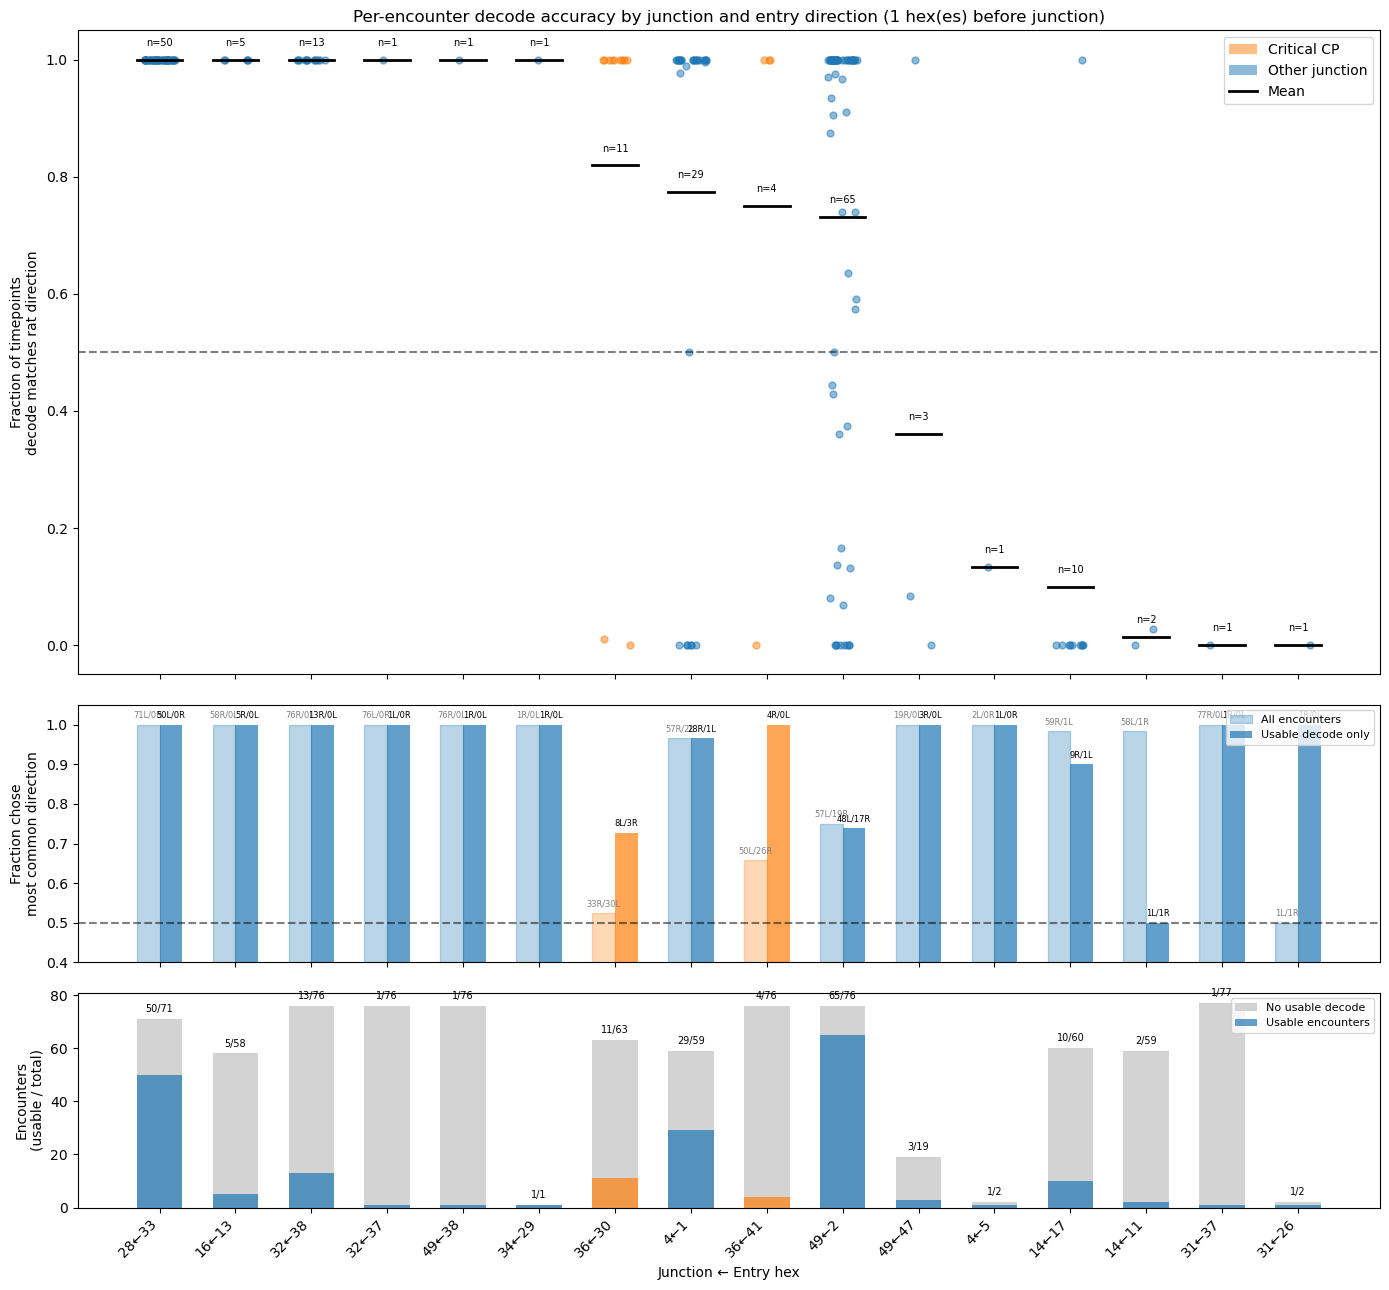

In [4]:
# ---- Self-contained: configure which distance from junction to analyze ----
# Set to 0 for "at the junction", -1 for "one hex before arrival", etc.
HEXES_FROM_JUNCTION = -1

def _most_common_frac(directions):
    """Fraction of encounters where the rat chose the most common direction."""
    counts = directions.value_counts()
    return counts.iloc[0] / len(directions)

def _most_common_label(directions):
    """Label string like '8L/2R' with the most common direction first."""
    n_left = (directions == "left").sum()
    n_right = (directions == "right").sum()
    if n_left >= n_right:
        return f"{n_left}L/{n_right}R"
    else:
        return f"{n_right}R/{n_left}L"

# Start from ALL timepoints at this distance from a junction (before quality filters)
# so we can count how many encounters had no usable decode output.
_all_at_dist = df[
    (df["hexes_from_junction"] == HEXES_FROM_JUNCTION)
    & (df["rat_junction_direction"].isin(["left", "right"]))
    & (df["epoch_trial_num"] > 1)
]

# Per-encounter rat direction for ALL encounters (before quality filtering)
all_encounter_stats = _all_at_dist.groupby(
    ["epoch_trial_num", "nearest_junction", "junction_entry_hex"]
).agg(
    rat_direction=("rat_junction_direction", "first"),
).reset_index()

# Count all encounters per (junction, entry_hex)
total_encounter_counts = all_encounter_stats.groupby(
    ["nearest_junction", "junction_entry_hex"]
).size().reset_index(name="n_total")

# Summarize choice bias across ALL encounters (before filtering)
all_choice_summary = all_encounter_stats.groupby(
    ["nearest_junction", "junction_entry_hex"]
).agg(
    frac_most_common_all=("rat_direction", _most_common_frac),
    choice_label_all=("rat_direction", _most_common_label),
).reset_index()

# Now apply quality filters
_filtered = df[
    (df["spatial_cov"] < 500)
    & (df["speed"] > 5)
    & (df["hexes_from_junction"] == HEXES_FROM_JUNCTION)
    & (df["rat_junction_direction"].isin(["left", "right"]))
    & (df["decode_junction_direction"].isin(["left", "right"]))
    & (df["epoch_trial_num"] > 1)
].copy()

_filtered["decode_matches"] = _filtered["decode_junction_direction"] == _filtered["rat_junction_direction"]

# Build per-block critical CP map (same logic as prediction cell)
_block_critical_cps = {}
for block_row in (HexMazeBlock() & key).fetch(as_dict=True):
    maze = block_row["config_id"]
    _block_critical_cps[block_row["block"]] = get_critical_choice_points(maze)

_filtered["is_critical_cp"] = _filtered.apply(
    lambda row: row["nearest_junction"] in _block_critical_cps.get(row["block"], set()),
    axis=1,
)

# Per-encounter stats: for each trial pass through a (junction, entry_hex),
# get the decode accuracy AND the rat's actual choice direction.
# We take the rat direction from the first timepoint (it's constant within
# an encounter — the rat only goes one way).
encounter_stats = _filtered.groupby(
    ["epoch_trial_num", "nearest_junction", "junction_entry_hex", "is_critical_cp"]
).agg(
    accuracy=("decode_matches", "mean"),
    rat_direction=("rat_junction_direction", "first"),
    n_timepoints=("decode_matches", "count"),
).reset_index()

# Count filtered encounters per (junction, entry_hex)
filtered_encounter_counts = encounter_stats.groupby(
    ["nearest_junction", "junction_entry_hex"]
).size().reset_index(name="n_filtered")

# Merge to get n_dropped = encounters that had zero usable timepoints
encounter_yield = total_encounter_counts.merge(
    filtered_encounter_counts, on=["nearest_junction", "junction_entry_hex"], how="left"
)
encounter_yield["n_filtered"] = encounter_yield["n_filtered"].fillna(0).astype(int)
encounter_yield["n_dropped"] = encounter_yield["n_total"] - encounter_yield["n_filtered"]

entry_summary = encounter_stats.groupby(
    ["nearest_junction", "junction_entry_hex", "is_critical_cp"]
).agg(
    mean_accuracy=("accuracy", "mean"),
    sem_accuracy=("accuracy", "sem"),
    n_encounters=("accuracy", "count"),
    # Choice bias from usable-decode encounters only
    frac_most_common=("rat_direction", _most_common_frac),
    choice_label=("rat_direction", _most_common_label),
).reset_index()

# Merge in encounter yield and ALL-encounter choice bias
entry_summary = entry_summary.merge(
    encounter_yield, on=["nearest_junction", "junction_entry_hex"], how="left"
)
entry_summary = entry_summary.merge(
    all_choice_summary, on=["nearest_junction", "junction_entry_hex"], how="left"
)
entry_summary = entry_summary.sort_values("mean_accuracy", ascending=False).reset_index(drop=True)

# Build x-axis labels like "junction←entry"
entry_summary["label"] = (
    entry_summary["nearest_junction"].astype(int).astype(str)
    + "←"
    + entry_summary["junction_entry_hex"].astype(int).astype(str)
)

label_to_x = {row["label"]: i for i, row in entry_summary.iterrows()}
pair_to_crit = dict(zip(
    zip(entry_summary["nearest_junction"], entry_summary["junction_entry_hex"]),
    entry_summary["is_critical_cp"],
))

fig, axes = plt.subplots(3, 1, figsize=(max(14, len(entry_summary) * 0.8), 13),
                         sharex=True, gridspec_kw={"height_ratios": [3, 1.2, 1]})

# --- Top panel: decode accuracy with per-encounter dots ---
ax = axes[0]
for _, row in encounter_stats.iterrows():
    pair = (row["nearest_junction"], row["junction_entry_hex"])
    label = f"{int(row['nearest_junction'])}←{int(row['junction_entry_hex'])}"
    if label not in label_to_x:
        continue
    x = label_to_x[label]
    is_crit = pair_to_crit.get(pair, False)
    color = "tab:orange" if is_crit else "tab:blue"
    jitter = np.random.uniform(-0.2, 0.2)
    ax.plot(x + jitter, row["accuracy"], "o", color=color, alpha=0.5, markersize=5)

# Overlay mean as black horizontal bars, annotate n
for i, row in entry_summary.iterrows():
    ax.plot([i - 0.3, i + 0.3], [row["mean_accuracy"], row["mean_accuracy"]], "k-", lw=2)
    ax.annotate(f"n={int(row['n_encounters'])}", (i, row["mean_accuracy"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=7)

ax.axhline(0.5, color="k", linestyle="--", alpha=0.5, label="Chance")
ax.set_ylabel("Fraction of timepoints\ndecode matches rat direction")
dist_label = "at junction" if HEXES_FROM_JUNCTION == 0 else f"{abs(HEXES_FROM_JUNCTION)} hex(es) before junction"
ax.set_title(f"Per-encounter decode accuracy by junction and entry direction ({dist_label})")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor="tab:orange", alpha=0.5, label="Critical CP"),
    Patch(facecolor="tab:blue", alpha=0.5, label="Other junction"),
    Line2D([0], [0], color="k", lw=2, label="Mean"),
], loc="upper right")

# --- Middle panel: rat choice bias — all encounters vs usable-decode only ---
# Side-by-side bars: left = all encounters, right = usable encounters.
# If filtering preferentially drops one choice direction, these will diverge.
ax2 = axes[1]
bar_width = 0.3
for i, row in entry_summary.iterrows():
    is_crit = row["is_critical_cp"]
    color = "tab:orange" if is_crit else "tab:blue"
    # All encounters (lighter, left)
    ax2.bar(i - bar_width / 2, row["frac_most_common_all"], color=color,
            alpha=0.3, width=bar_width, edgecolor=color)
    ax2.annotate(row["choice_label_all"], (i - bar_width / 2, row["frac_most_common_all"]),
                 textcoords="offset points", xytext=(0, 5),
                 ha="center", fontsize=6, color="gray")
    # Usable encounters (solid, right)
    ax2.bar(i + bar_width / 2, row["frac_most_common"], color=color,
            alpha=0.7, width=bar_width)
    ax2.annotate(row["choice_label"], (i + bar_width / 2, row["frac_most_common"]),
                 textcoords="offset points", xytext=(0, 5),
                 ha="center", fontsize=6)

ax2.axhline(0.5, color="k", linestyle="--", alpha=0.5)
ax2.set_ylim(0.4, 1.05)
ax2.set_ylabel("Fraction chose\nmost common direction")
ax2.legend(handles=[
    Patch(facecolor="tab:blue", alpha=0.3, edgecolor="tab:blue", label="All encounters"),
    Patch(facecolor="tab:blue", alpha=0.7, label="Usable decode only"),
], loc="upper right", fontsize=8)

# --- Bottom panel: encounter yield (how many encounters had usable decode) ---
# Shows total encounters as full bar, with the dropped portion in gray.
# High drop rates mean the decode was often low-confidence or the rat was
# stationary at this junction — results based on few survivors may be noisy.
ax3 = axes[2]
for i, row in entry_summary.iterrows():
    is_crit = row["is_critical_cp"]
    color = "tab:orange" if is_crit else "tab:blue"
    # Total encounters (lighter, behind)
    ax3.bar(i, row["n_total"], color="lightgray", width=0.6)
    # Usable encounters (colored, in front)
    ax3.bar(i, row["n_filtered"], color=color, alpha=0.7, width=0.6)
    ax3.annotate(f"{int(row['n_filtered'])}/{int(row['n_total'])}",
                 (i, row["n_total"]),
                 textcoords="offset points", xytext=(0, 5),
                 ha="center", fontsize=7)

ax3.set_ylabel("Encounters\n(usable / total)")
ax3.set_xlabel("Junction ← Entry hex")
ax3.set_xticks(range(len(entry_summary)))
ax3.set_xticklabels(entry_summary["label"], rotation=45, ha="right")

from matplotlib.patches import Patch as _Patch
ax3.legend(handles=[
    _Patch(facecolor="lightgray", label="No usable decode"),
    _Patch(facecolor="tab:blue", alpha=0.7, label="Usable encounters"),
], loc="upper right", fontsize=8)

plt.tight_layout()

In [ ]:
# Same breakdown but weighted by time: encounters with more timepoints
# contribute proportionally more to the mean. Instead of averaging
# per-encounter accuracies (which gives equal weight to a 5-timepoint
# pass and a 50-timepoint pass), this pools all timepoints for each
# (junction, entry_hex) pair and computes the overall fraction correct.

# Count correct and total timepoints per encounter
encounter_counts = filtered.groupby(
    ["epoch_trial_num", "nearest_junction", "junction_entry_hex", "is_critical_cp"]
)["decode_matches"].agg(["sum", "count"]).reset_index()
encounter_counts.columns = [
    "epoch_trial_num", "nearest_junction", "junction_entry_hex",
    "is_critical_cp", "n_correct", "n_total",
]

# Pool timepoints across encounters for each (junction, entry_hex)
pooled = encounter_counts.groupby(
    ["nearest_junction", "junction_entry_hex", "is_critical_cp"]
)[["n_correct", "n_total"]].sum().reset_index()
pooled["accuracy"] = pooled["n_correct"] / pooled["n_total"]

# For SEM: use binomial SE = sqrt(p*(1-p)/n) since each timepoint is a
# binary match/mismatch and we're pooling across all of them
pooled["sem"] = np.sqrt(
    pooled["accuracy"] * (1 - pooled["accuracy"]) / pooled["n_total"]
)
pooled = pooled.sort_values("accuracy", ascending=False).reset_index(drop=True)

# Build labels and mappings (same format as unweighted plot)
pooled["label"] = (
    pooled["nearest_junction"].astype(int).astype(str)
    + "←"
    + pooled["junction_entry_hex"].astype(int).astype(str)
)
label_to_x = {row["label"]: i for i, row in pooled.iterrows()}
pair_to_crit = dict(zip(
    zip(pooled["nearest_junction"], pooled["junction_entry_hex"]),
    pooled["is_critical_cp"],
))

fig, ax = plt.subplots(figsize=(max(14, len(pooled) * 0.8), 6))

# Plot per-encounter accuracies as jittered dots (same as before, for context)
for _, row in encounter_counts.iterrows():
    label = f"{int(row['nearest_junction'])}←{int(row['junction_entry_hex'])}"
    if label not in label_to_x:
        continue
    x = label_to_x[label]
    pair = (row["nearest_junction"], row["junction_entry_hex"])
    is_crit = pair_to_crit.get(pair, False)
    color = "tab:orange" if is_crit else "tab:blue"
    # Scale dot size by number of timepoints in that encounter
    size = np.clip(row["n_total"] / 2, 3, 20)
    jitter = np.random.uniform(-0.2, 0.2)
    enc_acc = row["n_correct"] / row["n_total"]
    ax.plot(x + jitter, enc_acc, "o", color=color, alpha=0.4, markersize=size)

# Overlay pooled (time-weighted) mean as black horizontal bars
for i, row in pooled.iterrows():
    ax.plot([i - 0.3, i + 0.3], [row["accuracy"], row["accuracy"]], "k-", lw=2)
    ax.annotate(f"n={int(row['n_total'])}tp", (i, row["accuracy"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=7)

ax.axhline(0.5, color="k", linestyle="--", alpha=0.5, label="Chance")
ax.set_xticks(range(len(pooled)))
ax.set_xticklabels(pooled["label"], rotation=45, ha="right")
ax.set_xlabel("Junction ← Entry hex")
ax.set_ylabel("Fraction of timepoints decode matches rat direction")
ax.set_title("Per-encounter decode accuracy by junction and entry direction\n(time-weighted: mean pools all timepoints, dot size ∝ encounter duration)")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor="tab:orange", alpha=0.5, label="Critical CP"),
    Patch(facecolor="tab:blue", alpha=0.5, label="Other junction"),
    Line2D([0], [0], color="k", lw=2, label="Pooled mean"),
])

plt.tight_layout()

## Decode anticipation

Does the decode predict the rat's turn *before* it arrives at the junction?
Plot decode accuracy as a function of distance from the junction.

In [ ]:
filtered = df[
    (df["spatial_cov"] < 500)
    & (df["speed"] > 5)
    & (df["nearest_junction"] != -100)
    & (df["rat_junction_direction"].isin(["left", "right"]))
    & (df["decode_junction_direction"].isin(["left", "right"]))
    & (df["epoch_trial_num"] > 1)
].copy()

filtered["decode_matches"] = filtered["decode_junction_direction"] == filtered["rat_junction_direction"]

# Per-trial accuracy at each distance from junction
trial_by_dist = filtered.groupby(
    ["epoch_trial_num", "hexes_from_junction"]
)["decode_matches"].mean().reset_index(name="accuracy")

stats = trial_by_dist.groupby("hexes_from_junction")["accuracy"].agg(["mean", "sem", "count"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(stats.index, stats["mean"], yerr=stats["sem"], marker="o", capsize=3)
ax.axhline(0.5, color="k", linestyle="--", alpha=0.5, label="Chance")
ax.axvline(0, color="gray", linestyle=":", alpha=0.5, label="At junction")
ax.set_xlabel("Hexes from junction (negative = approaching)")
ax.set_ylabel("Fraction decode matches rat direction")
ax.set_title("Decode anticipation around junctions")
ax.legend()

# Annotate with trial counts
for x, row in stats.iterrows():
    ax.annotate(f'n={int(row["count"])}', (x, row["mean"]),
               textcoords="offset points", xytext=(0, 10), ha="center", fontsize=7)

plt.tight_layout()

## Dead-end junctions

At junctions where one exit leads to a dead end, the "correct" choice is more
deterministic. Does the decode show stronger prediction here?

In [ ]:
from hexmaze import classify_maze_hexes

# For each block's maze, identify which junction exits lead to dead ends.
# This must be done per-block since different blocks can have different mazes.
block_dead_end_junctions = {}

for block_row in (HexMazeBlock() & key).fetch(as_dict=True):
    maze = block_row["config_id"]
    classification = classify_maze_hexes(maze)
    dead_end_hexes = classification.get("dead_end_hexes", set())
    junctions = get_all_choice_points(maze)
    graph = maze_to_graph(maze)

    dead_end_set = set()
    for j in junctions:
        neighbors = set(graph.neighbors(j))
        # A junction has a dead-end exit if any neighbor is a dead-end hex
        if neighbors & dead_end_hexes:
            dead_end_set.add(j)
    block_dead_end_junctions[block_row["block"]] = dead_end_set

print("Junctions with a dead-end exit per block:")
for b, de in block_dead_end_junctions.items():
    print(f"  Block {b}: {sorted(de)}")

# Compare decode accuracy at dead-end junctions vs non-dead-end junctions
filtered = df[
    (df["spatial_cov"] < 500)
    & (df["speed"] > 5)
    & (df["hexes_from_junction"] == 0)
    & (df["rat_junction_direction"].isin(["left", "right"]))
    & (df["decode_junction_direction"].isin(["left", "right"]))
    & (df["epoch_trial_num"] > 1)
].copy()

filtered["decode_matches"] = filtered["decode_junction_direction"] == filtered["rat_junction_direction"]

# Label per-timepoint using the correct block's dead-end junctions
filtered["is_dead_end_junction"] = filtered.apply(
    lambda row: row["nearest_junction"] in block_dead_end_junctions.get(row["block"], set()),
    axis=1,
)

trial_acc = filtered.groupby(
    ["epoch_trial_num", "is_dead_end_junction"]
)["decode_matches"].mean().reset_index(name="accuracy")

fig, ax = plt.subplots(figsize=(6, 5))
for label, group in trial_acc.groupby("is_dead_end_junction"):
    name = "Dead-end junction" if label else "Non-dead-end junction"
    mean_acc = group["accuracy"].mean()
    sem_acc = group["accuracy"].sem()
    ax.bar(name, mean_acc, yerr=sem_acc, capsize=5)
    ax.annotate(f"n={len(group)}", (name, mean_acc), textcoords="offset points",
               xytext=(0, 10), ha="center", fontsize=9)

ax.axhline(0.5, color="k", linestyle="--", alpha=0.5)
ax.set_ylabel("Fraction decode matches rat direction")
ax.set_title("Decode accuracy: dead-end vs non-dead-end junctions")
plt.tight_layout()

## Maze visualization

Plot the maze with junction left/right exits labeled.

In [ ]:
# Plot each block's maze with junctions labeled and critical CPs highlighted
centroids = get_hex_centroids()
blocks = (HexMazeBlock() & key).fetch(as_dict=True, order_by="block")

fig, axes = plt.subplots(1, len(blocks), figsize=(12 * len(blocks), 10))
if len(blocks) == 1:
    axes = [axes]

for ax, block_row in zip(axes, blocks):
    maze = block_row["config_id"]
    block_num = block_row["block"]

    lr_map = get_junction_left_right_map(maze, centroids)
    junctions = get_all_choice_points(maze)
    critical_cps = get_critical_choice_points(maze)
    graph = maze_to_graph(maze)

    plot_hex_maze(maze, centroids=centroids, ax=ax)

    # For each junction, pick the first entry direction and draw left/right arrows
    for j in junctions:
        neighbors = sorted(graph.neighbors(j))
        entry = neighbors[0]
        if (j, entry) not in lr_map:
            continue
        lr = lr_map[(j, entry)]
        jx, jy = centroids[j]

        # Draw arrows to left (blue) and right (red) exits
        for direction, color in [("left", "blue"), ("right", "red")]:
            ex, ey = centroids[lr[direction]]
            dx, dy = (ex - jx) * 0.4, (ey - jy) * 0.4
            ax.annotate("", xy=(jx + dx, jy + dy), xytext=(jx, jy),
                        arrowprops=dict(arrowstyle="->", color=color, lw=2))

        # Label the junction — orange bold for critical CPs, black for others
        is_crit = j in critical_cps
        ax.text(jx, jy, str(j), ha="center", va="center", fontsize=8,
                fontweight="bold",
                color="tab:orange" if is_crit else "black",
                bbox=dict(facecolor="white", edgecolor="tab:orange" if is_crit else "none",
                          boxstyle="round,pad=0.2", alpha=0.8) if is_crit else None)

    ax.set_title(f"Block {block_num} — Maze {maze}\n"
                 f"Left (blue) / Right (red) exits  |  "
                 f"Critical CPs in orange\n"
                 f"(entry from first neighbor)")

plt.tight_layout()